# 02 — ANÁLISIS DE 01_MODEL_TRAINING (sin entrenamiento)

Este notebook NO entrena modelos. Todos los resultados se generan a partir
de checkpoints previamente calculados.

Fuente de los resultados: 01_MODEL_TRAINING.ipynb (notebook de entrenamiento,
intacto, no se modifica ni se vuelve a ejecutar). Este notebook solo carga
los checkpoints (.pkl + .keras) generados por 01_MODEL_TRAINING.ipynb y recalcula tablas, figuras y análisis de residuales a partir de ellos — sin llamar en ningún momento a model.fit(), entrenar_modelo() ni entrenar_multisemilla().

## Alcance de este notebook
Carga los 3 checkpoints existentes: v16_mse, v16_huber015, v16_huber015_lr.

Reconstruye únicamente las fechas (dfs_merged) desde Datos_Embalses_Merged.xlsx — no repite la limpieza/imputación/merge de 01_MODEL_TRAINING.ipynb (Fase 1), que ya está congelada en ese archivo.

Verifica automáticamente que las métricas recalculadas coinciden con las métricas almacenadas en los checkpoints, antes de generar ninguna tabla o figura.

Reproduce, sin reentrenar: selección de configuración de pérdida (Wilcoxon + Holm-Bonferroni), tabla resumen final de test, comparación MLP vs. LSTM, ensemble por mediana, curvas de entrenamiento, predicciones vs. reales, análisis de residuales (incl. Ljung-Box) y el pronóstico iterativo de 30 días ya existente.

No modifica arquitecturas, hiperparámetros, semillas, partición train/val/test, funciones de pérdida, tratamiento de precipitación, tratamiento de ΔVolumen ni criterios estadísticos.

## Importaciones

In [1]:
# Importaciones (subconjunto necesario para análisis — sin utilidades de entrenamiento)

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
from scipy.stats import gaussian_kde, wilcoxon, norm
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, kpss
import tensorflow as tf  # solo se usa para tf.keras.models.load_model (inferencia, no entrenamiento)

## Rutas de Archivos (idénticas a 01_MODEL_TRAINING.ipynb)

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("No se detectó Google Colab: se omite el montaje de Drive.")

Mounted at /content/drive


In [3]:
# RUTAS — apuntan exactamente a donde 01_MODEL_TRAINING.ipynb guardó los checkpoints

RUTA_BASE    = os.environ.get('EMBALSES_RUTA_BASE', '/content/drive/MyDrive/Embalses/Pronostico/')
RUTA_DATOS   = RUTA_BASE + 'Datos_base/'
RUTA_FIGURAS = RUTA_BASE + 'Figuras/'

RUTA_CHECKPOINTS = os.path.join(RUTA_FIGURAS, 'checkpoints')
RUTA_MODELOS     = os.path.join(RUTA_CHECKPOINTS, 'models')

print('RUTA_CHECKPOINTS:', RUTA_CHECKPOINTS)
print('RUTA_MODELOS    :', RUTA_MODELOS)

RUTA_CHECKPOINTS: /content/drive/MyDrive/Embalses/Pronostico/Figuras/checkpoints
RUTA_MODELOS    : /content/drive/MyDrive/Embalses/Pronostico/Figuras/checkpoints/models


## 1. Reconstrucción liviana de `dfs_merged` (solo fechas)

No se repite la Fase 1 de `Version15.ipynb` (lectura de Excel crudos, limpieza,
imputación, merge, ADF/KPSS). Esa etapa ya está congelada en
`Datos_Embalses_Merged.xlsx`. Aquí solo se relee ese archivo para recuperar el
índice `Fecha` de cada embalse (necesario para el eje temporal de las figuras
y para las fechas reales del pronóstico), tal como ya estaba documentado en un
comentario de `Version15.ipynb` (Celda 12).


In [4]:
# Reconstrucción liviana de dfs_merged desde el Excel ya fusionado (sin reprocesar nada)

dfs_merged = {}
for embalse, hoja in [('Sisga', 'Sisga'), ('Neusa', 'Neusa'), ('Tominé', 'Tomine')]:
    df = pd.read_excel(RUTA_DATOS + 'Datos_Embalses_Merged.xlsx', sheet_name=hoja)
    df['Fecha'] = pd.to_datetime(df['Fecha'])
    dfs_merged[embalse] = df.set_index('Fecha')

for embalse, df in dfs_merged.items():
    print(f"{embalse:8s} — n={len(df)} | rango: {df.index.min().date()} → {df.index.max().date()}")

Sisga    — n=6940 | rango: 2006-01-01 → 2024-12-31
Neusa    — n=6940 | rango: 2006-01-01 → 2024-12-31
Tominé   — n=6940 | rango: 2006-01-01 → 2024-12-31


## 2. Carga de checkpoints (sin reentrenar)

`cargar_completo()` es exactamente la misma función definida en
`01_MODEL_TRAINING.ipynb` (Celda 18): relee el `.pkl` liviano de cada configuración y reinyecta el modelo `.keras` real correspondiente a cada semilla. No se invoca en ningún momento `guardar_completo()` ni `entrenar_multisemilla()`.

In [5]:
def cargar_completo(nombre_config: str) -> dict:
    """Recarga el pickle ligero e inyecta los modelos Keras reales.
    Copia idéntica de la función definida en 01_MODEL_TRAINING.ipynb (Celda 18).
    No entrena nada: solo lee archivos ya generados.
    """
    ruta_pickle = os.path.join(RUTA_CHECKPOINTS, f'{nombre_config}.pkl')
    with open(ruta_pickle, 'rb') as f:
        resultados = pickle.load(f)
    for embalse, modelos in resultados.items():
        for arq, corridas in modelos.items():
            for r in corridas:
                ruta_modelo = os.path.join(RUTA_MODELOS, f'{nombre_config}__{embalse}__{arq}__seed{r["seed"]}.keras')
                r['model'] = tf.keras.models.load_model(ruta_modelo)
    return resultados

In [6]:
# Carga de las 3 configuraciones ya entrenadas — no llamadas a entrenar_modelo/entrenar_multisemilla

print("Cargando checkpoints existentes (sin reentrenar)...")

resultados_multi          = cargar_completo('v16_mse')
resultados_multi_huber    = cargar_completo('v16_huber015')
resultados_multi_huber_lr = cargar_completo('v16_huber015_lr')

CONFIGS = {
    'mse':      resultados_multi,
    'huber':    resultados_multi_huber,
    'huber_lr': resultados_multi_huber_lr,
}

n_modelos_cargados = sum(
    len(corridas)
    for config in CONFIGS.values()
    for modelos in config.values()
    for corridas in modelos.values()
)
print(f"Checkpoints cargados: {list(CONFIGS.keys())}")
print(f"Total de modelos .keras reinyectados: {n_modelos_cargados}")

Cargando checkpoints existentes (sin reentrenar)...
Checkpoints cargados: ['mse', 'huber', 'huber_lr']
Total de modelos .keras reinyectados: 180


## 3. Verificación automática: métricas recalculadas vs. métricas almacenadas

Dos capas de verificación, ninguna modifica ni reentrena nada:

1. **Consistencia interna del pickle** — para las 180 corridas (3 configs ×
   3 embalses × 2 arquitecturas × 10 semillas), se recalculan MAE/RMSE/MAPE/R²
   con `sklearn.metrics` a partir de `pred`/`y_real` ya almacenados, y se
   comparan con los valores guardados (`np.isclose`).
2. **Spot-check de inferencia** — para una muestra (la primera semilla de cada
   combinación embalse×arquitectura×config, 18 de 180), se vuelve a correr
   `model.predict(X_test)` sobre el `.keras` cargado, se reconstruye el
   volumen exactamente como en `_bloque()` (01_MODEL_TRAINING, Celda 17), y se
   compara con la predicción almacenada. Esto confirma que el `.keras`
   coincide con lo que generó el `.pkl` — es inferencia, no entrenamiento.

In [7]:
# Capa 1 — Consistencia interna del pickle (recalcular métricas desde pred/y_real ya guardados)

def verificar_metricas_almacenadas(configs: dict, atol: float = 1e-6) -> pd.DataFrame:
    filas = []
    for nombre_config, resultados in configs.items():
        for embalse, modelos in resultados.items():
            for arq, corridas in modelos.items():
                for r in corridas:
                    for split in ('val', 'test'):
                        bloque = r[split]
                        y_real = bloque['y_real']
                        pred   = bloque['pred']

                        mae_recalc  = mean_absolute_error(y_real, pred)
                        rmse_recalc = np.sqrt(mean_squared_error(y_real, pred))
                        r2_recalc   = r2_score(y_real, pred)

                        ok_mae  = np.isclose(mae_recalc,  bloque['mae'],  atol=atol)
                        ok_rmse = np.isclose(rmse_recalc, bloque['rmse'], atol=atol)
                        ok_r2   = np.isclose(r2_recalc,   bloque['r2'],   atol=atol)

                        filas.append({
                            'config': nombre_config, 'embalse': embalse, 'arquitectura': arq,
                            'seed': r['seed'], 'split': split,
                            'MAE OK': bool(ok_mae), 'RMSE OK': bool(ok_rmse), 'R2 OK': bool(ok_r2),
                        })
    return pd.DataFrame(filas)


df_verificacion_metricas = verificar_metricas_almacenadas(CONFIGS)

n_total  = len(df_verificacion_metricas)
n_ok     = int((df_verificacion_metricas[['MAE OK', 'RMSE OK', 'R2 OK']].all(axis=1)).sum())
n_fallos = n_total - n_ok

print(f"Verificación de consistencia interna (pred/y_real almacenados vs. métricas almacenadas)")
print(f"Filas verificadas (config x embalse x arq x semilla x split): {n_total}")
print(f"  OK    : {n_ok}")
print(f"  FALLOS: {n_fallos}")

if n_fallos > 0:
    print("\n¡ATENCIÓN! Filas con discrepancia (revisar antes de continuar):")
    print(df_verificacion_metricas[~df_verificacion_metricas[['MAE OK', 'RMSE OK', 'R2 OK']].all(axis=1)])
else:
    print("\nTodas las métricas recalculadas coinciden con las almacenadas en los checkpoints. ✓")

Verificación de consistencia interna (pred/y_real almacenados vs. métricas almacenadas)
Filas verificadas (config x embalse x arq x semilla x split): 360
  OK    : 360
  FALLOS: 0

Todas las métricas recalculadas coinciden con las almacenadas en los checkpoints. ✓


In [8]:
# Capa 2 — Spot-check de inferencia (recorre model.predict en una muestra, sin reentrenar)

def verificar_inferencia_muestra(configs: dict, atol: float = 1e-4) -> pd.DataFrame:
    """Para la primera semilla de cada (config, embalse, arquitectura), vuelve a
    correr model.predict(X_test) y reconstruye el volumen exactamente como
    _bloque() en 01_MODEL_TRAINING (Celda 17), comparando contra lo almacenado.
    Es inferencia sobre un modelo ya entrenado — no hay fit() en ningún punto.
    """
    filas = []
    for nombre_config, resultados in configs.items():
        for embalse, modelos in resultados.items():
            for arq, corridas in modelos.items():
                r = corridas[0]  # primera semilla de esta combinación

                model      = r['model']
                scaler_vol = r['scaler_vol']
                X_test     = r['X_test']
                vol_t_minus_1 = r['test']['vol_t_minus_1']

                pred_delta_scaled = model.predict(X_test, verbose=0)
                pred_delta = scaler_vol.inverse_transform(pred_delta_scaled).flatten()
                pred_recalc = (vol_t_minus_1 + pred_delta).reshape(-1, 1)

                pred_almacenado = r['test']['pred']
                coincide = np.allclose(pred_recalc, pred_almacenado, atol=atol)

                mae_recalc = mean_absolute_error(r['test']['y_real'], pred_recalc)

                filas.append({
                    'config': nombre_config, 'embalse': embalse, 'arquitectura': arq,
                    'seed': r['seed'],
                    'MAE almacenado': r['test']['mae'], 'MAE recalculado (predict)': mae_recalc,
                    'Predicciones idénticas': bool(coincide),
                })
    return pd.DataFrame(filas)


df_verificacion_inferencia = verificar_inferencia_muestra(CONFIGS)
print("Spot-check de inferencia (model.predict sobre .keras cargado, muestra de "
      f"{len(df_verificacion_inferencia)}/{n_modelos_cargados} corridas)")
print(df_verificacion_inferencia.round(6).to_string(index=False))

if df_verificacion_inferencia['Predicciones idénticas'].all():
    print("\nTodas las predicciones recalculadas coinciden con las almacenadas. ✓")
else:
    print("\n¡ATENCIÓN! Alguna corrida no coincide — revisar antes de continuar.")

Spot-check de inferencia (model.predict sobre .keras cargado, muestra de 18/180 corridas)
  config embalse arquitectura  seed  MAE almacenado  MAE recalculado (predict)  Predicciones idénticas
     mse   Sisga          MLP    42        0.125076                   0.125076                    True
     mse   Sisga         LSTM    42        0.100849                   0.100849                    True
     mse   Neusa          MLP    42        0.077343                   0.077343                    True
     mse   Neusa         LSTM    42        0.067454                   0.067454                    True
     mse  Tominé          MLP    42        0.349340                   0.349340                    True
     mse  Tominé         LSTM    42        0.304989                   0.304989                    True
   huber   Sisga          MLP    42        0.117775                   0.117775                    True
   huber   Sisga         LSTM    42        0.100314                   0.100314        

## 4. Selección de configuración de pérdida (Wilcoxon + Holm-Bonferroni)

Copia idéntica de la lógica de `01_MODEL_TRAINING.ipynb` (Celdas 24-25). Criterio: MAE en validación, Wilcoxon pareado (N=10), Holm-Bonferroni **dentro de cada combinación embalse×arquitectura** (m=2 candidatos vs. baseline MSE). El test set no participa en esta decisión.

In [9]:
# Holm-Bonferroni — copia idéntica de 01_MODEL_TRAINING.ipynb (Celda 24)

def holm_bonferroni(pvalues: list, alpha: float = 0.05):
    """Devuelve (p_ajustados, rechazos) usando el método de Holm-Bonferroni."""
    pvalues = np.asarray(pvalues, dtype=float)
    m = len(pvalues)
    orden = np.argsort(pvalues)
    ajustados = np.empty(m)
    p_prev = 0.0
    for rank, idx in enumerate(orden):
        ajustado = min((m - rank) * pvalues[idx], 1.0)
        ajustado = max(ajustado, p_prev)
        ajustados[idx] = ajustado
        p_prev = ajustado
    rechazos = ajustados < alpha
    return ajustados, rechazos

In [11]:
# Selección de configuración — copia idéntica de 01_MODEL_TRAINING.ipynb (Celda 25)

def _mae_val_por_semilla(corridas: list) -> np.ndarray:
    return np.array([r['val']['mae'] for r in corridas])


def seleccionar_configuracion(configs: dict, dfs: dict,
                               baseline: str = 'mse',
                               alpha: float = 0.05) -> tuple:
    embalses      = list(dfs.keys())
    arquitecturas = list(next(iter(configs.values()))[embalses[0]].keys())
    candidatos    = [c for c in configs if c != baseline]

    seleccion      = {}
    filas_detalle  = []

    for embalse in embalses:
        seleccion[embalse] = {}
        for arq in arquitecturas:
            maes = {nombre: _mae_val_por_semilla(configs[nombre][embalse][arq])
                    for nombre in configs}

            p_raw = []
            for c in candidatos:
                try:
                    _, p = wilcoxon(maes[c], maes[baseline])
                except ValueError:
                    p = np.nan
                p_raw.append(p)

            p_validos = [p if not np.isnan(p) else 1.0 for p in p_raw]
            p_adj, rechazos = holm_bonferroni(p_validos, alpha=alpha)

            for c, p_r, p_a, rech in zip(candidatos, p_raw, p_adj, rechazos):
                filas_detalle.append({
                    'Embalse': embalse, 'Arquitectura': arq, 'Config': c,
                    'MAE val candidato (media)': np.mean(maes[c]),
                    'MAE val MSE (media)':       np.mean(maes[baseline]),
                    'Δ MAE (candidato − MSE)':   np.mean(maes[c]) - np.mean(maes[baseline]),
                    'p crudo (vs MSE)':          p_r,
                    'p ajustado (Holm)':         p_a,
                    'Significativo (α=0.05)':    bool(rech),
                    'Candidato mejora a MSE':    bool(rech and np.mean(maes[c]) < np.mean(maes[baseline])),
                })

            ganador   = baseline
            mejor_mae = np.mean(maes[baseline])
            for c, p_a, rech in zip(candidatos, p_adj, rechazos):
                mae_c = np.mean(maes[c])
                if rech and mae_c < mejor_mae:
                    ganador, mejor_mae = c, mae_c

            seleccion[embalse][arq] = {
                'config_ganadora': ganador,
                'corridas':        configs[ganador][embalse][arq],
                'mae_val_medio':   mejor_mae,
            }

    df_detalle = pd.DataFrame(filas_detalle)
    return seleccion, df_detalle


seleccion, df_seleccion_detalle = seleccionar_configuracion(CONFIGS, dfs_merged, baseline='mse')

print("DETALLE DE LA SELECCIÓN DE CONFIGURACIÓN")
print("Criterio: MAE en VALIDACIÓN (Mm³) — Wilcoxon pareado N=10, Holm-Bonferroni")
print("=" * 100)
print(df_seleccion_detalle.round(4).to_string(index=False))

print("\nCONFIGURACIÓN GANADORA POR EMBALSE Y ARQUITECTURA")
for embalse, por_arq in seleccion.items():
    for arq, info in por_arq.items():
        print(f"  {embalse:8s} | {arq:5s} -> {info['config_ganadora']:9s} "
              f"(MAE val medio = {info['mae_val_medio']:.4f} Mm³)")

DETALLE DE LA SELECCIÓN DE CONFIGURACIÓN
Criterio: MAE en VALIDACIÓN (Mm³) — Wilcoxon pareado N=10, Holm-Bonferroni
Embalse Arquitectura   Config  MAE val candidato (media)  MAE val MSE (media)  Δ MAE (candidato − MSE)  p crudo (vs MSE)  p ajustado (Holm)  Significativo (α=0.05)  Candidato mejora a MSE
  Sisga          MLP    huber                     0.0893               0.0922                  -0.0029            0.8457             0.8457                   False                   False
  Sisga          MLP huber_lr                     0.0849               0.0922                  -0.0073            0.0488             0.0977                   False                   False
  Sisga         LSTM    huber                     0.0770               0.0792                  -0.0021            0.1934             0.1934                   False                   False
  Sisga         LSTM huber_lr                     0.0740               0.0792                  -0.0052            0.0039            

## ADF/KPSS sobre ΔVolumen

In [12]:
# Se realiza sobre ΔVOLUMEN, ya que las empleadas en 01_MODEL_TRAINING.ipynb
# se calculan sobre Volumen y Precipitación en NIVEL, no sobre ΔVolumen, que
# es la serie que realmente se modela

print("PRUEBAS DE ESTACIONARIEDAD SOBRE ΔVOLUMEN (serie efectivamente modelada)")
print("=" * 70)

filas_estacionariedad = []
for embalse in dfs_merged.keys():
    ref = seleccion[embalse]['MLP']['corridas'][0]
    dataset_abs = ref['dataset_abs'].flatten()
    delta = np.diff(dataset_abs)

    adf_stat, adf_p, *_ = adfuller(delta, autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(delta, regression='c', nlags='auto')

    filas_estacionariedad.append({
        'Embalse': embalse,
        'ADF stat': adf_stat, 'ADF p': adf_p,
        'ADF: estacionaria (p<0.05)': adf_p < 0.05,
        'KPSS stat': kpss_stat, 'KPSS p': kpss_p,
        'KPSS: estacionaria (p>0.05)': kpss_p > 0.05,
    })
    print(f"{embalse:8s} | ADF stat={adf_stat:8.3f} p={adf_p:.4g}  |  "
          f"KPSS stat={kpss_stat:6.3f} p={kpss_p:.4g}")

df_estacionariedad_delta = pd.DataFrame(filas_estacionariedad)
print()
print(df_estacionariedad_delta.round(4).to_string(index=False))

PRUEBAS DE ESTACIONARIEDAD SOBRE ΔVOLUMEN (serie efectivamente modelada)


/tmp/ipykernel_443/3342865179.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(delta, regression='c', nlags='auto')


Sisga    | ADF stat=  -8.842 p=1.656e-14  |  KPSS stat= 0.019 p=0.1


/tmp/ipykernel_443/3342865179.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(delta, regression='c', nlags='auto')


Neusa    | ADF stat= -10.716 p=3.247e-19  |  KPSS stat= 0.031 p=0.1
Tominé   | ADF stat=  -7.872 p=4.961e-12  |  KPSS stat= 0.174 p=0.1

Embalse  ADF stat  ADF p  ADF: estacionaria (p<0.05)  KPSS stat  KPSS p  KPSS: estacionaria (p>0.05)
  Sisga   -8.8423    0.0                        True     0.0188     0.1                         True
  Neusa  -10.7156    0.0                        True     0.0310     0.1                         True
 Tominé   -7.8718    0.0                        True     0.1743     0.1                         True


/tmp/ipykernel_443/3342865179.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(delta, regression='c', nlags='auto')


## 5. Tabla resumen final (test) — copia idéntica de 01_MODEL_TRAINING.ipynb (Celda 26)

In [13]:
# Función para la tabla resumen

def construir_tabla_resumen(seleccion: dict) -> pd.DataFrame:
    filas = []
    for embalse, por_arq in seleccion.items():
        for arq, info in por_arq.items():
            corridas  = info['corridas']
            maes      = np.array([r['test']['mae']  for r in corridas])
            rmses     = np.array([r['test']['rmse'] for r in corridas])
            mapes     = np.array([r['test']['mape'] for r in corridas])
            r2s       = np.array([r['test']['r2']   for r in corridas])
            mae_naive = corridas[0]['test']['mae_naive']
            skills    = maes / mae_naive

            try:
                stat, p_vs_naive = wilcoxon(maes - mae_naive)
            except ValueError:
                stat, p_vs_naive = np.nan, np.nan

            filas.append({
                'Embalse': embalse, 'Arquitectura': arq,
                'Config ganadora':   info['config_ganadora'],
                'N semillas':        len(corridas),
                'MAE (media±DE)':    f"{maes.mean():.3f} ± {maes.std():.3f}",
                'RMSE (media±DE)':   f"{rmses.mean():.3f} ± {rmses.std():.3f}",
                'MAPE % (media±DE)': f"{mapes.mean():.2f} ± {mapes.std():.2f}",
                'R2 (media±DE)':     f"{r2s.mean():.6f} ± {r2s.std():.6f}",
                'R2 (min-max)':      f"{r2s.min():.6f} - {r2s.max():.6f}",
                'MAE Naive (deriva)': f"{mae_naive:.3f}",
                'Skill (media±DE)':  f"{skills.mean():.4f} ± {skills.std():.4f}",
                'Wilcoxon stat (vs Naive)': f"{stat:.3f}" if not np.isnan(stat) else "N/A",
                'Wilcoxon p (vs Naive)':    f"{p_vs_naive:.4f}" if not np.isnan(p_vs_naive) else "N/A",
                'Conclusión vs Naive': ('Supera al Naive ✓'
                                        if (not np.isnan(p_vs_naive) and p_vs_naive < 0.05
                                            and skills.mean() < 1)
                                        else 'No se diferencia / no supera al Naive'),
            })
    return pd.DataFrame(filas)

df_resumen_final = construir_tabla_resumen(seleccion)
print("TABLA RESUMEN FINAL — TEST (N semillas por configuración ganadora, incluye R2 por arquitectura)")
print("=" * 110)
print(df_resumen_final.to_string(index=False))

TABLA RESUMEN FINAL — TEST (N semillas por configuración ganadora, incluye R2 por arquitectura)
Embalse Arquitectura Config ganadora  N semillas MAE (media±DE) RMSE (media±DE) MAPE % (media±DE)       R2 (media±DE)        R2 (min-max) MAE Naive (deriva) Skill (media±DE) Wilcoxon stat (vs Naive) Wilcoxon p (vs Naive)                   Conclusión vs Naive
  Sisga          MLP             mse          10  0.122 ± 0.012   0.215 ± 0.011       0.20 ± 0.02 0.999745 ± 0.000026 0.999684 - 0.999780              0.106  1.1517 ± 0.1088                    0.000                0.0020 No se diferencia / no supera al Naive
  Sisga         LSTM        huber_lr          10  0.095 ± 0.001   0.194 ± 0.001       0.16 ± 0.00 0.999793 ± 0.000001 0.999790 - 0.999795              0.106  0.8942 ± 0.0075                    0.000                0.0020                     Supera al Naive ✓
  Neusa          MLP        huber_lr          10  0.076 ± 0.002   0.126 ± 0.003       0.09 ± 0.00 0.999886 ± 0.000006 0.999876 

## 6. Comparación entre arquitecturas (MLP vs. LSTM) — copia idéntica de 01_MODEL_TRAINING.ipynb (Celda 27)

In [14]:
def comparar_arquitecturas(seleccion: dict, alpha: float = 0.05) -> tuple:
    filas    = []
    p_raw    = []
    embalses = list(seleccion.keys())

    for embalse in embalses:
        maes_mlp  = np.array([r['test']['mae'] for r in seleccion[embalse]['MLP']['corridas']])
        maes_lstm = np.array([r['test']['mae'] for r in seleccion[embalse]['LSTM']['corridas']])
        try:
            stat, p = wilcoxon(maes_mlp, maes_lstm)
        except ValueError:
            stat, p = np.nan, np.nan
        p_raw.append(p if not np.isnan(p) else 1.0)
        filas.append({'Embalse': embalse,
                      'MAE MLP (media)':  maes_mlp.mean(),
                      'MAE LSTM (media)': maes_lstm.mean(),
                      'Wilcoxon stat': stat, 'p crudo': p})

    p_adj, rechazos = holm_bonferroni(p_raw, alpha=alpha)
    mejor_por_embalse = {}
    for fila, p_a, rech in zip(filas, p_adj, rechazos):
        fila['p ajustado (Holm)'] = p_a
        if rech:
            ganador = 'MLP' if fila['MAE MLP (media)'] < fila['MAE LSTM (media)'] else 'LSTM'
        else:
            ganador = 'Empate (p≥0.05)'
        fila['Ganador'] = ganador
        mejor_por_embalse[fila['Embalse']] = (ganador if ganador != 'Empate (p≥0.05)'
                                               else ('MLP' if fila['MAE MLP (media)'] < fila['MAE LSTM (media)']
                                                     else 'LSTM'))

    return pd.DataFrame(filas), mejor_por_embalse


df_arquitecturas, mejor_por_embalse = comparar_arquitecturas(seleccion)

print("COMPARACIÓN MLP vs LSTM (cada una en su configuración ganadora) — TEST, N=10, Holm-Bonferroni")
print("=" * 95)
print(df_arquitecturas.round(4).to_string(index=False))
print()
for embalse, ganador in mejor_por_embalse.items():
    empató = (df_arquitecturas.loc[df_arquitecturas['Embalse'] == embalse, 'Ganador'].iloc[0]
              == 'Empate (p≥0.05)')
    etiqueta = (f"{ganador} (sin diferencia estadísticamente significativa frente al otro)"
                if empató else ganador)
    print(f"  {embalse}: mejor modelo -> {etiqueta}")

COMPARACIÓN MLP vs LSTM (cada una en su configuración ganadora) — TEST, N=10, Holm-Bonferroni
Embalse  MAE MLP (media)  MAE LSTM (media)  Wilcoxon stat  p crudo  p ajustado (Holm) Ganador
  Sisga           0.1222            0.0949            0.0   0.0020             0.0059    LSTM
  Neusa           0.0757            0.0694            1.0   0.0039             0.0078    LSTM
 Tominé           0.3339            0.3119            6.0   0.0273             0.0273    LSTM

  Sisga: mejor modelo -> LSTM
  Neusa: mejor modelo -> LSTM
  Tominé: mejor modelo -> LSTM


## 7. Ensemble por mediana — copia idéntica de 01_MODEL_TRAINING.ipynb.ipynb (Celda 28)

In [15]:
def construir_ensemble(corridas: list, metodo: str = 'mediana') -> dict:
    pred_deltas     = np.stack([r['test']['pred_delta'] for r in corridas])
    pred_delta_ens  = (np.median(pred_deltas, axis=0) if metodo == 'mediana'
                       else pred_deltas.mean(axis=0))

    ref            = corridas[0]['test']
    vol_t_minus_1  = ref['vol_t_minus_1']
    y_real_delta   = ref['y_real_delta']
    naive_delta    = ref['naive_delta']
    mae_naive, rmse_naive, mape_naive = ref['mae_naive'], ref['rmse_naive'], ref['mape_naive']

    pred_vol_ens   = (vol_t_minus_1 + pred_delta_ens).reshape(-1, 1)
    y_real_vol     = (vol_t_minus_1 + y_real_delta).reshape(-1, 1)
    pred_naive_vol = (vol_t_minus_1 + naive_delta).reshape(-1, 1)

    mae  = mean_absolute_error(y_real_vol, pred_vol_ens)
    rmse = np.sqrt(mean_squared_error(y_real_vol, pred_vol_ens))
    mape = np.mean(np.abs((y_real_vol - pred_vol_ens) / y_real_vol)) * 100
    r2   = r2_score(y_real_vol, pred_vol_ens)
    residuales = (y_real_vol - pred_vol_ens).flatten()

    return {
        'y_real': y_real_vol, 'pred': pred_vol_ens, 'pred_naive': pred_naive_vol,
        'mae': mae, 'rmse': rmse, 'mape': mape, 'r2': r2,
        'mae_naive': mae_naive, 'rmse_naive': rmse_naive, 'mape_naive': mape_naive,
        'residuales': residuales,
        'seed': f"ensemble {metodo} (N={len(corridas)})",
        'metodo': metodo, 'n_semillas': len(corridas),
    }


corridas_ganadoras = {}
corridas_finales   = {}
for embalse in dfs_merged.keys():
    corridas_ganadoras[embalse] = {}
    corridas_finales[embalse]   = {}
    for arq in ['MLP', 'LSTM']:
        corridas = seleccion[embalse][arq]['corridas']
        corridas_ganadoras[embalse][arq] = corridas
        corridas_finales[embalse][arq]   = construir_ensemble(corridas, metodo='mediana')

print("ENSEMBLE POR MEDIANA — configuración ganadora por embalse/arquitectura")
print("=" * 78)
filas_ens = []
for embalse in dfs_merged.keys():
    for arq in ['MLP', 'LSTM']:
        ens  = corridas_finales[embalse][arq]
        maes = [r['test']['mae'] for r in corridas_ganadoras[embalse][arq]]
        skill_ensemble = ens['mae'] / ens['mae_naive']
        filas_ens.append({
            'Embalse': embalse, 'Arquitectura': arq,
            'Config': seleccion[embalse][arq]['config_ganadora'],
            'MAE individual (media)':    np.mean(maes),
            'MAE ensemble (mediana)':    ens['mae'],
            'RMSE ensemble (mediana)':   ens['rmse'],
            'Skill ensemble (mediana)':  skill_ensemble,
            '¿Supera al Naive? (ensemble)': 'Sí ✓' if skill_ensemble < 1 else 'No ✗',
            '¿Mediana mejora al promedio individual?': 'Sí' if ens['mae'] < np.mean(maes) else 'No',
        })
df_ensemble = pd.DataFrame(filas_ens)
print(df_ensemble.round(4).to_string(index=False))

ENSEMBLE POR MEDIANA — configuración ganadora por embalse/arquitectura
Embalse Arquitectura   Config  MAE individual (media)  MAE ensemble (mediana)  RMSE ensemble (mediana)  Skill ensemble (mediana) ¿Supera al Naive? (ensemble) ¿Mediana mejora al promedio individual?
  Sisga          MLP      mse                  0.1222                  0.1031                   0.1973                    0.9721                         Sí ✓                                      Sí
  Sisga         LSTM huber_lr                  0.0949                  0.0945                   0.1938                    0.8907                         Sí ✓                                      Sí
  Neusa          MLP huber_lr                  0.0757                  0.0703                   0.1191                    0.9366                         Sí ✓                                      Sí
  Neusa         LSTM      mse                  0.0694                  0.0685                   0.1170                    0.9125         

## 8. Figuras — reproducción idéntica (sin cambios de formato todavía)

Las siguientes figuras se generan con el mismo código de `01_MODEL_TRAINING.ipynb` (Celdas 29-33), a partir de los datos ya cargados.

### 8.1 Curvas de entrenamiento (loss / val_loss)

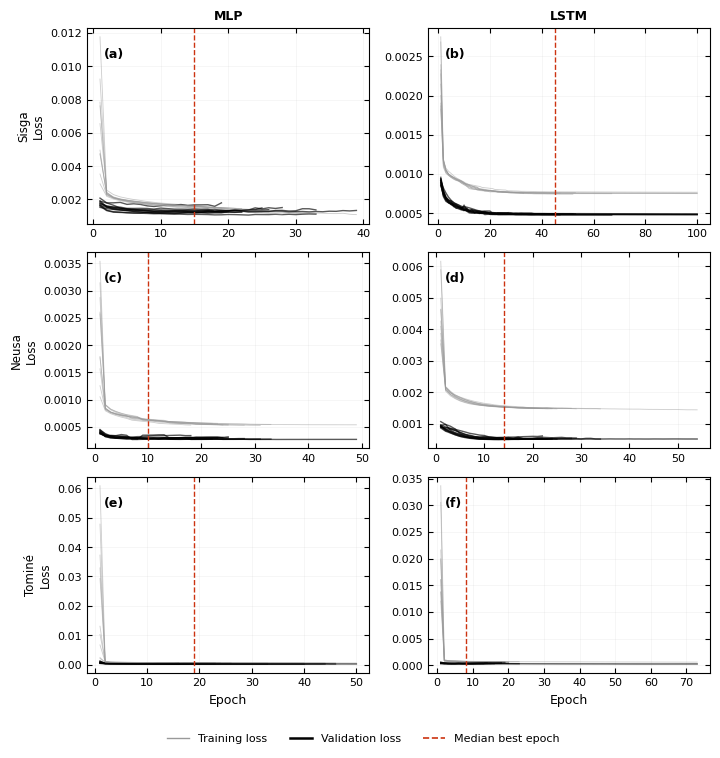

Figura 1 guardada en: /content/drive/MyDrive/Embalses/Pronostico/Figuras_Paper/


In [16]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.0,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

COLOR_TRAIN = '#999999'
COLOR_VAL   = '#000000'
COLOR_REF   = '#CC3311'
LW_TRAIN, ALPHA_TRAIN = 0.6, 0.50
LW_VAL,   ALPHA_VAL   = 1.0, 0.65

RUTA_FIGURAS_PAPER = RUTA_BASE + 'Figuras_Paper/'
os.makedirs(RUTA_FIGURAS_PAPER + 'pdf/', exist_ok=True)
os.makedirs(RUTA_FIGURAS_PAPER + 'png/', exist_ok=True)

embalses_orden = list(dfs_merged.keys())
arquitecturas  = ['MLP', 'LSTM']
n_embalses     = len(embalses_orden)

fig, axes = plt.subplots(n_embalses, 2, figsize=(7.2, 7.5))
axes = np.atleast_2d(axes)

panel_letras = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
i_letra = 0

for fila, embalse in enumerate(embalses_orden):
    for col, arq in enumerate(arquitecturas):
        corridas = corridas_ganadoras[embalse][arq]
        ax = axes[fila, col]

        mejores_epocas = []
        for r in corridas:
            hist = r['history'].history if hasattr(r['history'], 'history') else r['history']
            ep = np.arange(1, len(hist['loss']) + 1)
            ax.plot(ep, hist['loss'],     color=COLOR_TRAIN, linewidth=LW_TRAIN, alpha=ALPHA_TRAIN)
            ax.plot(ep, hist['val_loss'], color=COLOR_VAL,   linewidth=LW_VAL,   alpha=ALPHA_VAL)
            mejores_epocas.append(int(np.argmin(hist['val_loss'])) + 1)

        mediana_ep = int(np.median(mejores_epocas))
        ax.axvline(mediana_ep, color=COLOR_REF, linestyle='--', linewidth=1.0)

        ax.tick_params(direction='in', top=True, right=True)
        ax.grid(alpha=0.15, linewidth=0.5)

        ax.text(0.06, 0.90, panel_letras[i_letra], transform=ax.transAxes,
                 fontsize=9, fontweight='bold', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.8))
        i_letra += 1

        if fila == 0:
            ax.set_title(arq, fontsize=9, fontweight='bold', pad=6)
        ax.set_ylabel(f'{embalse}\nLoss' if col == 0 else '', fontsize=8.5)
        if fila == n_embalses - 1:
            ax.set_xlabel('Epoch')

handles = [
    Line2D([0], [0], color=COLOR_TRAIN, lw=1.0, label='Training loss'),
    Line2D([0], [0], color=COLOR_VAL,   lw=1.8, label='Validation loss'),
    Line2D([0], [0], color=COLOR_REF,   lw=1.2, linestyle='--', label='Median best epoch'),
]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.035, 1, 1])

fig.savefig(f'{RUTA_FIGURAS_PAPER}pdf/Figure1_LossCurves.pdf', format='pdf', bbox_inches='tight')
fig.savefig(f'{RUTA_FIGURAS_PAPER}png/Figure1_LossCurves.png', format='png', dpi=600, bbox_inches='tight')
plt.show()
print("Figura 1 guardada en:", RUTA_FIGURAS_PAPER)

### 8.2 Predicciones vs. valores reales (test)

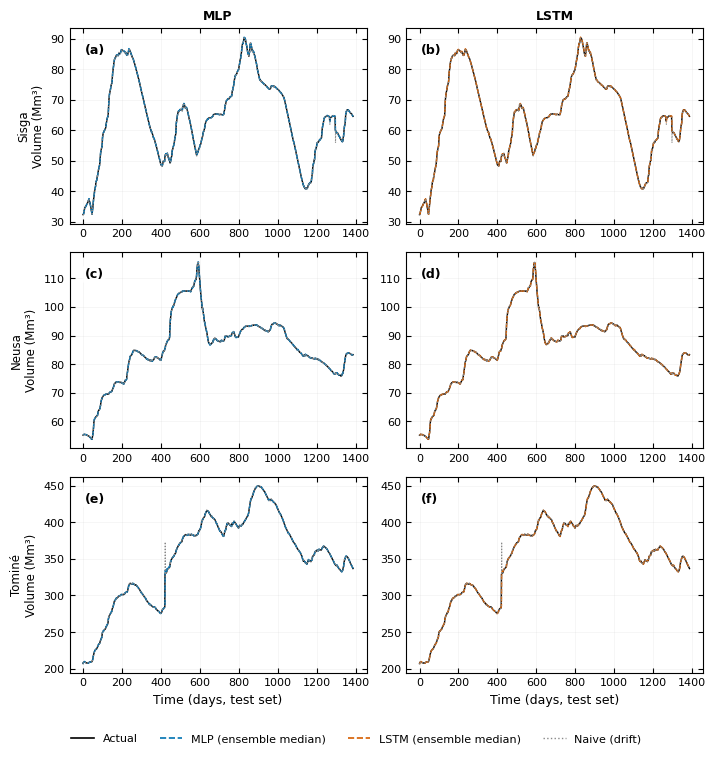

Figura S1 guardada en: /content/drive/MyDrive/Embalses/Pronostico/Figuras_Paper/


In [17]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.0,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

COLOR_ACTUAL = '#000000'
COLOR_NAIVE  = '#888888'
COLOR_MLP    = '#0072B2'
COLOR_LSTM   = '#D55E00'
COLOR_ARCH   = {'MLP': COLOR_MLP, 'LSTM': COLOR_LSTM}

RUTA_FIGURAS_PAPER = RUTA_BASE + 'Figuras_Paper/'
os.makedirs(RUTA_FIGURAS_PAPER + 'pdf/', exist_ok=True)
os.makedirs(RUTA_FIGURAS_PAPER + 'png/', exist_ok=True)

embalses_orden = list(dfs_merged.keys())
arquitecturas  = ['MLP', 'LSTM']

fig, axes = plt.subplots(len(embalses_orden), 2, figsize=(7.2, 7.5))
axes = np.atleast_2d(axes)

panel_letras = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
i_letra = 0

for fila, embalse in enumerate(embalses_orden):
    for col, arq in enumerate(arquitecturas):
        info = corridas_finales[embalse][arq]
        ax = axes[fila, col]

        y_r = info['y_real'].flatten()
        y_p = info['pred'].flatten()
        y_n = info['pred_naive'].flatten()

        ax.plot(y_r, color=COLOR_ACTUAL,    linewidth=1.0)
        ax.plot(y_p, color=COLOR_ARCH[arq], linewidth=1.0, linestyle='--')
        ax.plot(y_n, color=COLOR_NAIVE,     linewidth=0.8, linestyle=':')

        ax.text(0.05, 0.92, panel_letras[i_letra], transform=ax.transAxes,
                 fontsize=9, fontweight='bold', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.8))
        i_letra += 1

        ax.tick_params(direction='in', top=True, right=True)
        ax.grid(alpha=0.15, linewidth=0.5)

        if fila == 0:
            ax.set_title(arq, fontsize=9, fontweight='bold', pad=6)
        ax.set_ylabel(f'{embalse}\nVolume (Mm\u00b3)' if col == 0 else '', fontsize=8.5)
        if fila == len(embalses_orden) - 1:
            ax.set_xlabel('Time (days, test set)')

handles = [
    Line2D([0], [0], color=COLOR_ACTUAL, lw=1.2, label='Actual'),
    Line2D([0], [0], color=COLOR_MLP,    lw=1.2, linestyle='--', label='MLP (ensemble median)'),
    Line2D([0], [0], color=COLOR_LSTM,   lw=1.2, linestyle='--', label='LSTM (ensemble median)'),
    Line2D([0], [0], color=COLOR_NAIVE,  lw=1.0, linestyle=':',  label='Naive (drift)'),
]
fig.legend(handles=handles, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.035, 1, 1])

fig.savefig(f'{RUTA_FIGURAS_PAPER}pdf/FigureS1_Predictions_MLP_LSTM.pdf', format='pdf', bbox_inches='tight')
fig.savefig(f'{RUTA_FIGURAS_PAPER}png/FigureS1_Predictions_MLP_LSTM.png', format='png', dpi=600, bbox_inches='tight')
plt.show()
print("Figura S1 guardada en:", RUTA_FIGURAS_PAPER)

### 8.3 Mejor modelo por embalse (figura combinada)

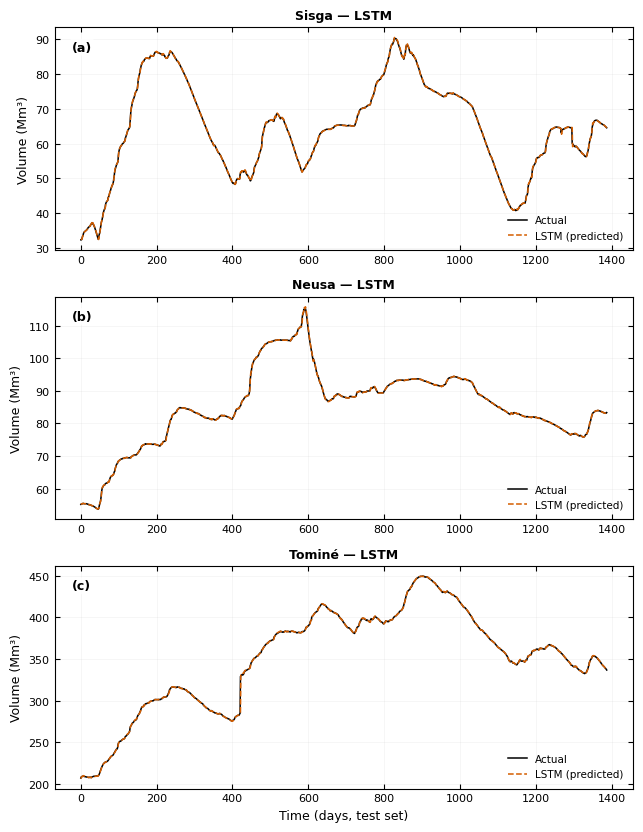

Figura 3 guardada en: /content/drive/MyDrive/Embalses/Pronostico/Figuras_Paper/


In [18]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.0,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

COLOR_ACTUAL = '#000000'
COLOR_MLP    = '#0072B2'
COLOR_LSTM   = '#D55E00'
COLOR_ARCH   = {'MLP': COLOR_MLP, 'LSTM': COLOR_LSTM}

RUTA_FIGURAS_PAPER = RUTA_BASE + 'Figuras_Paper/'
os.makedirs(RUTA_FIGURAS_PAPER + 'pdf/', exist_ok=True)
os.makedirs(RUTA_FIGURAS_PAPER + 'png/', exist_ok=True)

embalses_orden = list(dfs_merged.keys())
panel_letras = ['(a)', '(b)', '(c)']

fig, axes = plt.subplots(len(embalses_orden), 1, figsize=(6.5, 8.4))
axes = np.atleast_1d(axes)

for i, (ax, embalse) in enumerate(zip(axes, embalses_orden)):
    ganador = mejor_por_embalse[embalse]
    info    = corridas_finales[embalse][ganador]
    color   = COLOR_ARCH[ganador]

    y_r = info['y_real'].flatten()
    y_p = info['pred'].flatten()

    ax.plot(y_r, color=COLOR_ACTUAL, linewidth=1.1, label='Actual')
    ax.plot(y_p, color=color, linewidth=1.1, linestyle='--', label=f'{ganador} (predicted)')

    ax.text(0.03, 0.94, panel_letras[i], transform=ax.transAxes,
             fontsize=9, fontweight='bold', va='top', ha='left',
             bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.8))

    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(alpha=0.15, linewidth=0.5)
    ax.set_title(f'{embalse} \u2014 {ganador}', fontsize=9, fontweight='bold')
    ax.set_ylabel('Volume (Mm\u00b3)')
    if i == len(embalses_orden) - 1:
        ax.set_xlabel('Time (days, test set)')

    ax.legend(loc='lower right', frameon=False, fontsize=7.5, handlelength=1.8)

plt.tight_layout()

fig.savefig(f'{RUTA_FIGURAS_PAPER}pdf/Figure3_BestModel.pdf', format='pdf', bbox_inches='tight')
fig.savefig(f'{RUTA_FIGURAS_PAPER}png/Figure3_BestModel.png', format='png', dpi=600, bbox_inches='tight')
plt.show()
print("Figura 3 guardada en:", RUTA_FIGURAS_PAPER)

### 8.4 Análisis de residuales

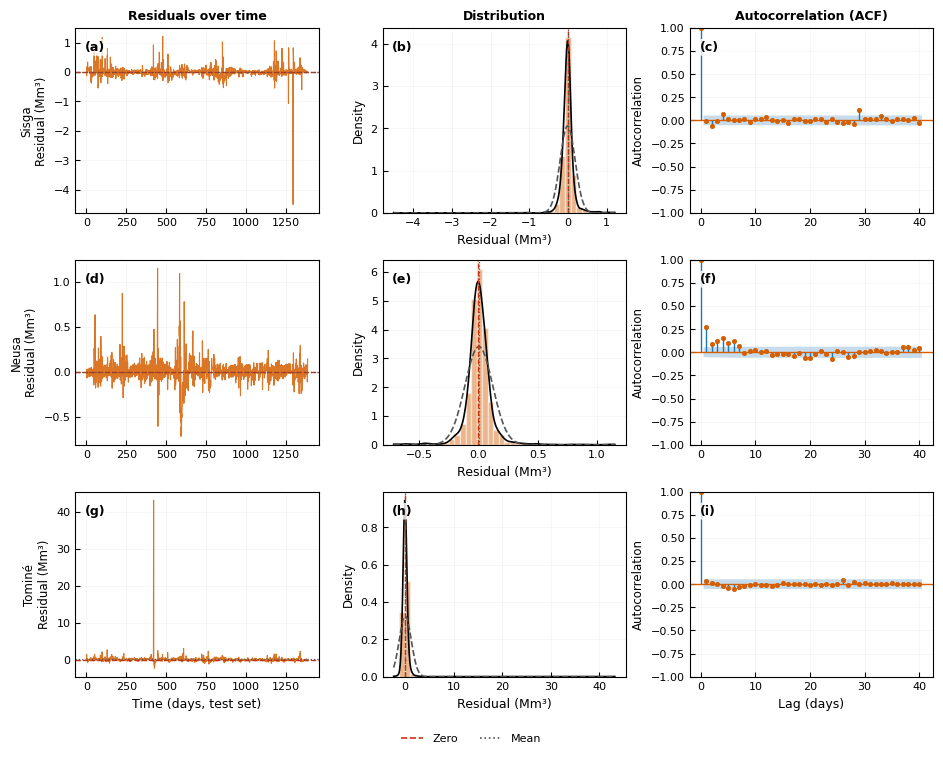

Figura 4 guardada en: /content/drive/MyDrive/Embalses/Pronostico/Figuras_Paper/


In [19]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.0,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

COLOR_MLP  = '#0072B2'
COLOR_LSTM = '#D55E00'
COLOR_ARCH = {'MLP': COLOR_MLP, 'LSTM': COLOR_LSTM}
COLOR_REF  = '#CC3311'
COLOR_MEAN = '#555555'

RUTA_FIGURAS_PAPER = RUTA_BASE + 'Figuras_Paper/'
os.makedirs(RUTA_FIGURAS_PAPER + 'pdf/', exist_ok=True)
os.makedirs(RUTA_FIGURAS_PAPER + 'png/', exist_ok=True)

embalses_orden = list(dfs_merged.keys())
columnas = ['Residuals over time', 'Distribution', 'Autocorrelation (ACF)']

lb_resultados = {}

fig, axes = plt.subplots(len(embalses_orden), 3, figsize=(9.5, 7.5))
axes = np.atleast_2d(axes)

letras = [f'({chr(ord("a")+k)})' for k in range(len(embalses_orden) * 3)]
i_letra = 0

for fila, embalse in enumerate(embalses_orden):
    ganador    = mejor_por_embalse[embalse]
    info       = corridas_finales[embalse][ganador]
    color      = COLOR_ARCH[ganador]
    residuales = info['residuales']
    n_res      = len(residuales)
    media_res  = float(np.mean(residuales))
    std_res    = float(np.std(residuales))
    pct_neg    = float(np.mean(residuales < 0) * 100)

    # Columna 0 — serie temporal
    ax = axes[fila, 0]
    ax.plot(residuales, color=color, linewidth=0.8, alpha=0.85)
    ax.axhline(0, color=COLOR_REF, linestyle='--', linewidth=1.0)
    ax.axhline(media_res, color=COLOR_MEAN, linestyle=':', linewidth=0.9)
    ax.text(0.04, 0.93, letras[i_letra], transform=ax.transAxes, fontsize=9, fontweight='bold',
             va='top', ha='left', bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.8))
    i_letra += 1
    ax.tick_params(direction='in'); ax.grid(alpha=0.15, linewidth=0.5)
    ax.set_ylabel(f'{embalse}\nResidual (Mm\u00b3)', fontsize=8.5)
    if fila == len(embalses_orden) - 1:
        ax.set_xlabel('Time (days, test set)')
    if fila == 0:
        ax.set_title(columnas[0], fontsize=9, fontweight='bold', pad=6)

    # Columna 1 — histograma + KDE + normal
    ax = axes[fila, 1]
    ax.hist(residuales, bins=40, color=color, alpha=0.45, edgecolor='white', density=True)
    eje_x = np.linspace(residuales.min(), residuales.max(), 300)
    kde   = gaussian_kde(residuales)
    ax.plot(eje_x, kde(eje_x), color='black', linewidth=1.2)
    ax.plot(eje_x, norm.pdf(eje_x, loc=media_res, scale=std_res), color=COLOR_MEAN, linewidth=1.2, linestyle='--')
    ax.axvline(0, color=COLOR_REF, linestyle='--', linewidth=1.0)
    ax.axvline(media_res, color=COLOR_MEAN, linestyle=':', linewidth=0.9)
    ax.text(0.04, 0.93, letras[i_letra], transform=ax.transAxes, fontsize=9, fontweight='bold',
             va='top', ha='left', bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.8))
    i_letra += 1
    ax.tick_params(direction='in'); ax.grid(alpha=0.15, linewidth=0.5)
    ax.set_ylabel('Density', fontsize=8.5)
    ax.set_xlabel('Residual (Mm\u00b3)')
    if fila == 0:
        ax.set_title(columnas[1], fontsize=9, fontweight='bold', pad=6)

    # Columna 2 — ACF
    ax = axes[fila, 2]
    plot_acf(residuales, lags=min(40, n_res // 4), ax=ax, color=color, title='')

    for ln in ax.lines:
      ln.set_markersize(3)
      ln.set_markeredgewidth(0.6)

    ax.text(0.04, 0.93, letras[i_letra], transform=ax.transAxes, fontsize=9, fontweight='bold',
             va='top', ha='left', bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.8))
    i_letra += 1
    ax.tick_params(direction='in'); ax.grid(alpha=0.15, linewidth=0.5)
    ax.set_ylabel('Autocorrelation', fontsize=8.5)
    if fila == len(embalses_orden) - 1:
        ax.set_xlabel('Lag (days)')
    if fila == 0:
        ax.set_title(columnas[2], fontsize=9, fontweight='bold', pad=6)

    lb = acorr_ljungbox(residuales, lags=[10, 20, 30], return_df=True)
    lb_resultados[embalse] = {
        'modelo': ganador, 'config': seleccion[embalse][ganador]['config_ganadora'],
        'info': info, 'media': media_res, 'std': std_res, 'pct_neg': pct_neg, 'lb': lb,
    }

handles = [
    Line2D([0], [0], color=COLOR_REF,  lw=1.2, linestyle='--', label='Zero'),
    Line2D([0], [0], color=COLOR_MEAN, lw=1.2, linestyle=':',  label='Mean'),
]
fig.legend(handles=handles, loc='lower center', ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.03, 1, 1])

fig.savefig(f'{RUTA_FIGURAS_PAPER}pdf/Figure4_Residuals.pdf', format='pdf', bbox_inches='tight')
fig.savefig(f'{RUTA_FIGURAS_PAPER}png/Figure4_Residuals.png', format='png', dpi=600, bbox_inches='tight')
plt.show()
print("Figura 4 guardada en:", RUTA_FIGURAS_PAPER)

### 8.5 Resultados numéricos de residuales y Ljung-Box

In [20]:
print("\n" + "=" * 70)
print("RESULTADOS NUMÉRICOS: RESIDUALES (VOLUMEN RECONSTRUIDO) Y TEST DE LJUNG-BOX")
print("=" * 70)

for embalse, res in lb_resultados.items():
    info  = res['info']
    skill = info['mae'] / info['mae_naive']
    print(f"\n{'─'*65}")
    print(f"Embalse : {embalse}   |   Modelo : {res['modelo']}   |   Config : {res['config']}")
    print(f"{'─'*65}")
    print(f"  MAE                  : {info['mae']:.4f} Mm³")
    print(f"  RMSE                 : {info['rmse']:.4f} Mm³")
    print(f"  MAPE                 : {info['mape']:.4f} %")
    print(f"  R²                   : {info['r2']:.6f}")
    print(f"  MAE naive (deriva)   : {info['mae_naive']:.4f} Mm³")
    print(f"  Skill ratio          : {skill:.4f}  "
          f"({'modelo mejora al naive ✓' if skill < 1 else 'modelo NO mejora al naive ✗'})")

    bias_ok = abs(res['media']) < info['mae'] * 0.05
    pct_ok  = abs(res['pct_neg'] - 50) < 10
    print(f"\n  Media residuales     : {res['media']:.4f} Mm³  "
          f"({'≈ 0, sin sesgo ✓' if bias_ok else 'SESGO DETECTADO ✗'})")
    print(f"  Desv. estándar       : {res['std']:.4f} Mm³")
    print(f"  % residuales < 0     : {res['pct_neg']:.1f}%  "
          f"({'≈ 50%, sin sesgo direccional ✓' if pct_ok else 'SESGO DIRECCIONAL ✗ (esperado ~50%)'})")

    print(f"\n  Ljung-Box — residuales (volumen reconstruido):")
    for idx, row in res['lb'].iterrows():
        marca = ("<- Rechaza H0 (autocorr. significativa)  ✗"
                 if row['lb_pvalue'] < 0.05 else "<- No rechaza H0  ✓")
        print(f"    Lag {int(idx):2d}:  Q={row['lb_stat']:7.3f}  p={row['lb_pvalue']:.4f}  {marca}")

print("\n" + "=" * 70)
print("FIN DEL ANÁLISIS NUMÉRICO — reproducido íntegramente desde checkpoints")
print("=" * 70)


RESULTADOS NUMÉRICOS: RESIDUALES (VOLUMEN RECONSTRUIDO) Y TEST DE LJUNG-BOX

─────────────────────────────────────────────────────────────────
Embalse : Sisga   |   Modelo : LSTM   |   Config : huber_lr
─────────────────────────────────────────────────────────────────
  MAE                  : 0.0945 Mm³
  RMSE                 : 0.1938 Mm³
  MAPE                 : 0.1569 %
  R²                   : 0.999794
  MAE naive (deriva)   : 0.1061 Mm³
  Skill ratio          : 0.8907  (modelo mejora al naive ✓)

  Media residuales     : -0.0068 Mm³  (SESGO DETECTADO ✗)
  Desv. estándar       : 0.1937 Mm³
  % residuales < 0     : 53.5%  (≈ 50%, sin sesgo direccional ✓)

  Ljung-Box — residuales (volumen reconstruido):
    Lag 10:  Q= 14.712  p=0.1429  <- No rechaza H0  ✓
    Lag 20:  Q= 19.379  p=0.4973  <- No rechaza H0  ✓
    Lag 30:  Q= 43.632  p=0.0515  <- No rechaza H0  ✓

─────────────────────────────────────────────────────────────────
Embalse : Neusa   |   Modelo : LSTM   |   Config : mse


## 9. Pronóstico multi-step iterativo — Escenario A (automático)

Copia idéntica de 01_MODEL_TRAINING.ipynb (Celdas 34-37). El punto de arranque se elige automáticamente por máxima variación conjunta observada en el propio test set. El Escenario B (evento/fecha específica) se trata por separado en la Sección 10; ambos escenarios se preservan y se comparan en la Sección 10.4.

### 9.1 Selección del punto de arranque (máxima variación conjunta)

In [21]:
ref_embalses = {
    embalse: seleccion[embalse]['MLP']['corridas'][0]['test']
    for embalse in dfs_merged.keys()
}

horizonte  = 30
n_test     = len(list(ref_embalses.values())[0]['y_real'])
variaciones = []

for idx in range(n_test - horizonte):
    var_total = 0
    for embalse, ref in ref_embalses.items():
        y = ref['y_real'].flatten()[idx:idx + horizonte]
        v = ref['vol_t_minus_1'][idx]
        var_total += np.std(y - v)
    variaciones.append((idx, var_total))

top5 = sorted(variaciones, key=lambda x: x[1], reverse=True)[:5]
print("Top 5 puntos de arranque por variación conjunta:")
for idx, var in top5:
    print(f"  idx={idx:4d}  variación conjunta={var:.3f}")
    for embalse, ref in ref_embalses.items():
        y = ref['y_real'].flatten()[idx:idx + horizonte]
        v = ref['vol_t_minus_1'][idx]
        print(f"    {embalse}: arranque={v:.2f}  día30={y[-1]:.2f}  "
              f"Δtotal={y[-1]-v:.2f}  "
              f"MAE_naive={mean_absolute_error(y, np.full(30, v)):.3f}")

IDX_ARRANQUE       = top5[0][0]
HORIZONTE_FORECAST = 30
print(f"\nÍndice de arranque seleccionado automáticamente: idx={IDX_ARRANQUE}")

Top 5 puntos de arranque por variación conjunta:
  idx= 405  variación conjunta=28.180
    Sisga: arranque=48.59  día30=52.12  Δtotal=3.53  MAE_naive=2.092
    Neusa: arranque=82.36  día30=88.12  Δtotal=5.76  MAE_naive=3.171
    Tominé: arranque=277.27  día30=335.65  Δtotal=58.38  MAE_naive=27.890
  idx= 406  variación conjunta=28.162
    Sisga: arranque=48.40  día30=51.83  Δtotal=3.43  MAE_naive=2.356
    Neusa: arranque=82.63  día30=88.21  Δtotal=5.58  MAE_naive=3.091
    Tominé: arranque=277.74  día30=335.92  Δtotal=58.18  MAE_naive=29.357
  idx= 407  variación conjunta=28.046
    Sisga: arranque=48.30  día30=51.48  Δtotal=3.18  MAE_naive=2.544
    Neusa: arranque=83.08  día30=88.30  Δtotal=5.23  MAE_naive=2.820
    Tominé: arranque=279.17  día30=336.19  Δtotal=57.03  MAE_naive=29.835
  idx= 404  variación conjunta=28.046
    Sisga: arranque=48.68  día30=52.27  Δtotal=3.59  MAE_naive=1.911
    Neusa: arranque=82.19  día30=88.03  Δtotal=5.84  MAE_naive=3.157
    Tominé: arranque=276.

### 9.2 Climatología de precipitación por día del año (sin fuga) para el pronóstico realista

El pronóstico recursivo original (Escenario A/B) alimenta, en cada paso futuro,
la precipitación REAL ya observada en el conjunto de test — información que en
un pronóstico operativo real (2 a 29 dias de anticipación) no se tendría.

Esta celda calcula una climatología de precipitación por día-del-año (media
histórica de lluvia para cada uno de los 366 días del calendario), usando
EXCLUSIVAMENTE el tramo de entrenamiento (train_raw), para no introducir
ninguna fuga de información desde validación/test.

Esa climatología se usa más adelante (modo_precip='climatologia') como
sustituto realista de la precipitación real dentro del pronóstico iterativo,
y permite cuantificar cuánto del skill reportado depende de conocer la lluvia
futura por adelantado.


In [22]:
def calcular_climatologia_precip(dataset_abs_index, precip_mm, train_raw):
    """
    Climatología de precipitación por día-del-año (media histórica),
    calculada SOLO con el tramo de entrenamiento (sin fuga).

    dataset_abs_index: índice de fechas (DatetimeIndex) de la serie completa
    precip_mm: array 1D de precipitación en mm, alineado con ese índice
    train_raw: número de observaciones de entrenamiento (mismo criterio que
               en entrenar_modelo: 70% de la serie diferenciada)
    """
    fechas_train  = dataset_abs_index[:train_raw]
    precip_train  = precip_mm[:train_raw]
    doy_train     = fechas_train.dayofyear
    clim = pd.Series(precip_train, index=doy_train).groupby(level=0).mean()
    # día 366 (bisiesto) puede faltar en algunos años de train; usar día 365 como respaldo
    if 366 not in clim.index and 365 in clim.index:
        clim.loc[366] = clim.loc[365]
    return clim

CLIMATOLOGIA_PRECIP = {}
for embalse in dfs_merged.keys():
    df_e = dfs_merged[embalse]
    ref  = seleccion[embalse]['MLP']['corridas'][0]
    CLIMATOLOGIA_PRECIP[embalse] = calcular_climatologia_precip(
        df_e.index, df_e['Precip_mm'].values, ref['train_raw']
    )
    print(f"{embalse}: climatología calculada sobre {ref['train_raw']} días de entrenamiento "
          f"(media anual = {CLIMATOLOGIA_PRECIP[embalse].mean():.2f} mm/dia)")

Sisga: climatología calculada sobre 4857 días de entrenamiento (media anual = 3.59 mm/dia)
Neusa: climatología calculada sobre 4857 días de entrenamiento (media anual = 2.32 mm/dia)
Tominé: climatología calculada sobre 4857 días de entrenamiento (media anual = 3.47 mm/dia)


### 9.3 Funciones de pronóstico iterativo (individual y ensemble)

In [23]:
def forecast_iterativo_individual(r: dict, idx: int, horizonte: int = 30,
                                   modo_precip: str = 'real',
                                   climatologia: pd.Series = None,
                                   fechas_test: pd.DatetimeIndex = None) -> np.ndarray:
    """
    Pronóstico multi-step iterativo para UNA semilla (bivariado).

    modo_precip:
      'real'         -> comportamiento ORIGINAL: usa la precipitación real
                        ya observada en X_test para cada paso futuro.
      'climatologia' -> sustituye la precipitación real por el promedio
                        historico de ese dia del año (climatologia,
                        calculada solo con train, sin fuga). Requiere pasar
                        'climatologia' (Series indexada 1..366) y
                        'fechas_test' (DatetimeIndex alineado a X_test).
      'cero'         -> sustituye la precipitacion futura por 0 en cada paso
                        (caso de referencia extremo).
    """
    assert modo_precip in ('real', 'climatologia', 'cero')
    if modo_precip == 'climatologia':
        assert climatologia is not None and fechas_test is not None, \
            "modo_precip='climatologia' requiere climatologia y fechas_test"

    model       = r['model']
    scaler_vol  = r['scaler_vol']
    scaler_prec = r['scaler_prec']
    formato_3d  = r['formato_3d']
    ventana     = r['ventana']

    ventana_actual = r['X_test'][idx].copy()
    vol_actual = float(r['test']['vol_t_minus_1'][idx])
    preds_vol  = []

    for h in range(horizonte):
        if formato_3d:
            entrada = ventana_actual.reshape(1, ventana, 2)
        else:
            entrada = ventana_actual.reshape(1, ventana * 2)

        delta_scaled = model.predict(entrada, verbose=0)
        delta        = float(scaler_vol.inverse_transform(delta_scaled)[0, 0])
        vol_actual  += delta
        preds_vol.append(vol_actual)

        nuevo_dvol = float(delta_scaled[0, 0])

        # Precipitación del siguiente paso, según modo_precip
        idx_siguiente = idx + h + 1
        if modo_precip == 'real':
            if idx_siguiente < len(r['X_test']):
                if formato_3d:
                    nuevo_prec = float(r['X_test'][idx_siguiente][-1, 1])
                else:
                    nuevo_prec = float(r['X_test'][idx_siguiente][2 * ventana - 1])
            else:
                if formato_3d:
                    nuevo_prec = float(ventana_actual[-1, 1])
                else:
                    nuevo_prec = float(ventana_actual[2 * ventana - 1])
        elif modo_precip == 'cero':
            nuevo_prec = float(scaler_prec.transform([[0.0]])[0, 0])
        else:  # climatologia
            fecha_h = fechas_test[idx_siguiente] if idx_siguiente < len(fechas_test) else fechas_test[-1]
            doy = fecha_h.dayofyear
            precip_clim_mm = float(climatologia.get(doy, climatologia.mean()))
            nuevo_prec = float(scaler_prec.transform([[precip_clim_mm]])[0, 0])

        if formato_3d:
            ventana_actual = np.roll(ventana_actual, -1, axis=0)
            ventana_actual[-1, 0] = nuevo_dvol
            ventana_actual[-1, 1] = nuevo_prec
        else:
            ventana_actual = np.roll(ventana_actual, -1)
            ventana_actual[ventana - 1]     = nuevo_dvol
            ventana_actual[2 * ventana - 1] = nuevo_prec

    return np.array(preds_vol)


def forecast_iterativo_ensemble(corridas: list, idx: int,
                                 horizonte: int = 30,
                                 metodo: str = 'mediana',
                                 modo_precip: str = 'real',
                                 climatologia: pd.Series = None,
                                 fechas_test: pd.DatetimeIndex = None) -> dict:
    trayectorias = np.stack([
        forecast_iterativo_individual(r, idx, horizonte,
                                       modo_precip=modo_precip,
                                       climatologia=climatologia,
                                       fechas_test=fechas_test)
        for r in corridas
    ])

    pred_vol_ens = (np.median(trayectorias, axis=0) if metodo == 'mediana'
                    else trayectorias.mean(axis=0))

    ref          = corridas[0]['test']
    y_real       = ref['y_real'].flatten()[idx:idx + horizonte]
    vol_arranque = float(ref['vol_t_minus_1'][idx])
    naive        = np.full(horizonte, vol_arranque)

    mae_modelo      = mean_absolute_error(y_real, pred_vol_ens)
    mae_naive_plano = mean_absolute_error(y_real, naive)
    skill = mae_modelo / mae_naive_plano if mae_naive_plano > 0 else np.nan

    return {
        'horizonte': horizonte, 'n_semillas': len(corridas), 'modo_precip': modo_precip,
        'pred_vol':             pred_vol_ens,
        'trayectorias':         trayectorias,
        'y_real_horizonte':     y_real,
        'pred_naive_horizonte': naive,
        'vol_arranque':         vol_arranque,
        'mae':                  mae_modelo,
        'mae_naive_plano':      mae_naive_plano,
        'skill':                skill,
    }

### 9.4 Ejecución del pronóstico — Escenario A

In [24]:
print(f"\nPRONÓSTICO MULTI-STEP ITERATIVO (30 días) — idx={IDX_ARRANQUE}, "
      f"máxima variación conjunta")
print("=" * 70)

forecasts = {}
for embalse in dfs_merged.keys():
    forecasts[embalse] = {}
    for arq in ['MLP', 'LSTM']:
        corridas = seleccion[embalse][arq]['corridas']
        fc = forecast_iterativo_ensemble(
            corridas, idx=IDX_ARRANQUE, horizonte=HORIZONTE_FORECAST
        )
        forecasts[embalse][arq] = fc
        print(f"{embalse:8s} — {arq:4s} (N={fc['n_semillas']}): "
              f"MAE={fc['mae']:.3f}  |  "
              f"Naive plano={fc['mae_naive_plano']:.3f}  |  "
              f"Skill={fc['skill']:.4f} "
              f"({'mejora ✓' if fc['skill'] < 1 else 'no mejora ✗'})")


PRONÓSTICO MULTI-STEP ITERATIVO (30 días) — idx=405, máxima variación conjunta
Sisga    — MLP  (N=10): MAE=5.448  |  Naive plano=2.092  |  Skill=2.6038 (no mejora ✗)
Sisga    — LSTM (N=10): MAE=0.353  |  Naive plano=2.092  |  Skill=0.1685 (mejora ✓)
Neusa    — MLP  (N=10): MAE=8.416  |  Naive plano=3.171  |  Skill=2.6537 (no mejora ✗)
Neusa    — LSTM (N=10): MAE=0.952  |  Naive plano=3.171  |  Skill=0.3001 (mejora ✓)
Tominé   — MLP  (N=10): MAE=138.435  |  Naive plano=27.890  |  Skill=4.9636 (no mejora ✗)
Tominé   — LSTM (N=10): MAE=23.766  |  Naive plano=27.890  |  Skill=0.8521 (mejora ✓)


### 9.5 Figura — Escenario A (30 días)

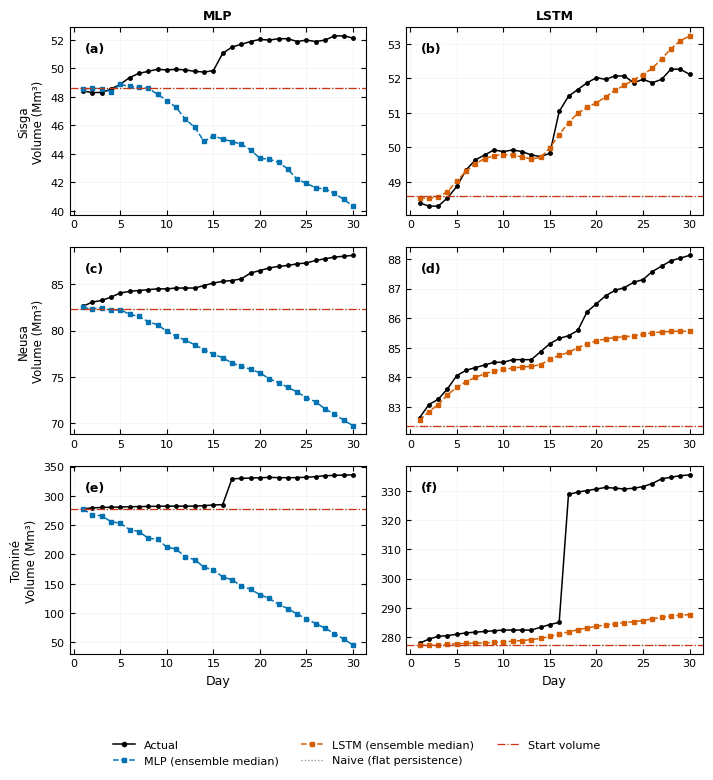

Figura 5 guardada en: /content/drive/MyDrive/Embalses/Pronostico/Figuras_Paper/


In [25]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.0,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

COLOR_ACTUAL = '#000000'
COLOR_NAIVE  = '#888888'
COLOR_MLP    = '#0072B2'
COLOR_LSTM   = '#D55E00'
COLOR_ARCH   = {'MLP': COLOR_MLP, 'LSTM': COLOR_LSTM}
COLOR_REF    = '#CC3311'

RUTA_FIGURAS_PAPER = RUTA_BASE + 'Figuras_Paper/'
os.makedirs(RUTA_FIGURAS_PAPER + 'pdf/', exist_ok=True)
os.makedirs(RUTA_FIGURAS_PAPER + 'png/', exist_ok=True)

embalses_orden = list(dfs_merged.keys())
arquitecturas  = ['MLP', 'LSTM']
panel_letras = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

fig, axes = plt.subplots(len(embalses_orden), 2, figsize=(7.2, 7.5))
axes = np.atleast_2d(axes)

i_letra = 0
dias = np.arange(1, HORIZONTE_FORECAST + 1)

for fila, embalse in enumerate(embalses_orden):
    for col, arq in enumerate(arquitecturas):
        fc = forecasts[embalse][arq]
        color = COLOR_ARCH[arq]
        ax = axes[fila, col]

        ax.plot(dias, fc['y_real_horizonte'], color=COLOR_ACTUAL, linewidth=1.1, marker='o', markersize=2.5)
        ax.plot(dias, fc['pred_vol'], color=color, linewidth=1.1, linestyle='--', marker='s', markersize=2.5)
        ax.plot(dias, fc['pred_naive_horizonte'], color=COLOR_NAIVE, linewidth=0.9, linestyle=':')
        ax.axhline(fc['vol_arranque'], color=COLOR_REF, linestyle='-.', linewidth=0.9)

        ax.text(0.05, 0.92, panel_letras[i_letra], transform=ax.transAxes,
                 fontsize=9, fontweight='bold', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.8))
        i_letra += 1

        ax.tick_params(direction='in', top=True, right=True)
        ax.grid(alpha=0.15, linewidth=0.5)

        if fila == 0:
            ax.set_title(arq, fontsize=9, fontweight='bold', pad=6)
        ax.set_ylabel(f'{embalse}\nVolume (Mm\u00b3)' if col == 0 else '', fontsize=8.5)
        if fila == len(embalses_orden) - 1:
            ax.set_xlabel('Day')

handles = [
    Line2D([0], [0], color=COLOR_ACTUAL, lw=1.1, marker='o', markersize=3, label='Actual'),
    Line2D([0], [0], color=COLOR_MLP,    lw=1.1, linestyle='--', marker='s', markersize=3, label='MLP (ensemble median)'),
    Line2D([0], [0], color=COLOR_LSTM,   lw=1.1, linestyle='--', marker='s', markersize=3, label='LSTM (ensemble median)'),
    Line2D([0], [0], color=COLOR_NAIVE,  lw=0.9, linestyle=':',  label='Naive (flat persistence)'),
    Line2D([0], [0], color=COLOR_REF,    lw=0.9, linestyle='-.', label='Start volume'),
]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout(rect=[0, 0.06, 1, 1])

fig.savefig(f'{RUTA_FIGURAS_PAPER}pdf/Figure5a_Forecast30d.pdf', format='pdf', bbox_inches='tight')
fig.savefig(f'{RUTA_FIGURAS_PAPER}png/Figure5a_Forecast30d.png', format='png', dpi=600, bbox_inches='tight')
plt.show()
print("Figura 5 guardada en:", RUTA_FIGURAS_PAPER)

Ahora teniendo en cuenta que no se conoce la precipitación futura:

### 9.6 Fechas reales del pronóstico — Escenario A

In [31]:
# Fechas empleadas en el pronóstico anterior (usa dfs_merged reconstruido en la sección 1)
for embalse in dfs_merged.keys():
    ref = seleccion[embalse]['MLP']['corridas'][0]
    n_train_val = ref['val_size'] + ref['ventana']
    idx_absoluto = n_train_val + IDX_ARRANQUE
    fecha     = dfs_merged[embalse].index[idx_absoluto]
    fecha_fin = dfs_merged[embalse].index[idx_absoluto + 29]
    print(f"{embalse}: {fecha.date()} → {fecha_fin.date()}")

Sisga: 2022-04-23 → 2022-05-22
Neusa: 2022-04-23 → 2022-05-22
Tominé: 2022-04-23 → 2022-05-22


### 9.7 COMPARACION: precipitacion real vs. climatologia

In [33]:
print("PRONOSTICO 30 DIAS — COMPARACION: precipitacion real (oraculo) vs. climatologia (realista)")
print("=" * 90)

forecasts_climatologia = {}
filas_comparacion_precip = []
for embalse in dfs_merged.keys():
    fechas_test_embalse = dfs_merged[embalse].index[
        seleccion[embalse]['MLP']['corridas'][0]['val_size'] + seleccion[embalse]['MLP']['corridas'][0]['ventana']:
    ]
    forecasts_climatologia[embalse] = {}
    for arq in ['MLP', 'LSTM']:
        corridas = seleccion[embalse][arq]['corridas']
        fc_real = forecasts[embalse][arq]   # ya calculado en la Celda 42 original (modo_precip='real')
        fc_clim = forecast_iterativo_ensemble(
            corridas, idx=IDX_ARRANQUE, horizonte=HORIZONTE_FORECAST,
            modo_precip='climatologia',
            climatologia=CLIMATOLOGIA_PRECIP[embalse],
            fechas_test=fechas_test_embalse,
        )
        forecasts_climatologia[embalse][arq] = fc_clim

        degradacion_pct = (fc_clim['skill'] - fc_real['skill']) / fc_real['skill'] * 100
        filas_comparacion_precip.append({
            'Embalse': embalse, 'Arquitectura': arq,
            'Skill (precip real, oraculo)': fc_real['skill'],
            'Skill (climatologia, realista)': fc_clim['skill'],
            'Degradacion skill (%)': degradacion_pct,
        })
        print(f"{embalse:8s} {arq:4s} | skill real={fc_real['skill']:.4f}  "
              f"skill climatologia={fc_clim['skill']:.4f}  "
              f"degradacion={degradacion_pct:+.1f}%")

df_comparacion_precip = pd.DataFrame(filas_comparacion_precip)

PRONOSTICO 30 DIAS — COMPARACION: precipitacion real (oraculo) vs. climatologia (realista)
Sisga    MLP  | skill real=2.6038  skill climatologia=4.0951  degradacion=+57.3%
Sisga    LSTM | skill real=0.1685  skill climatologia=0.9066  degradacion=+437.9%
Neusa    MLP  | skill real=2.6537  skill climatologia=2.8339  degradacion=+6.8%
Neusa    LSTM | skill real=0.3001  skill climatologia=0.4738  degradacion=+57.9%
Tominé   MLP  | skill real=4.9636  skill climatologia=5.1273  degradacion=+3.3%
Tominé   LSTM | skill real=0.8521  skill climatologia=0.9752  degradacion=+14.4%


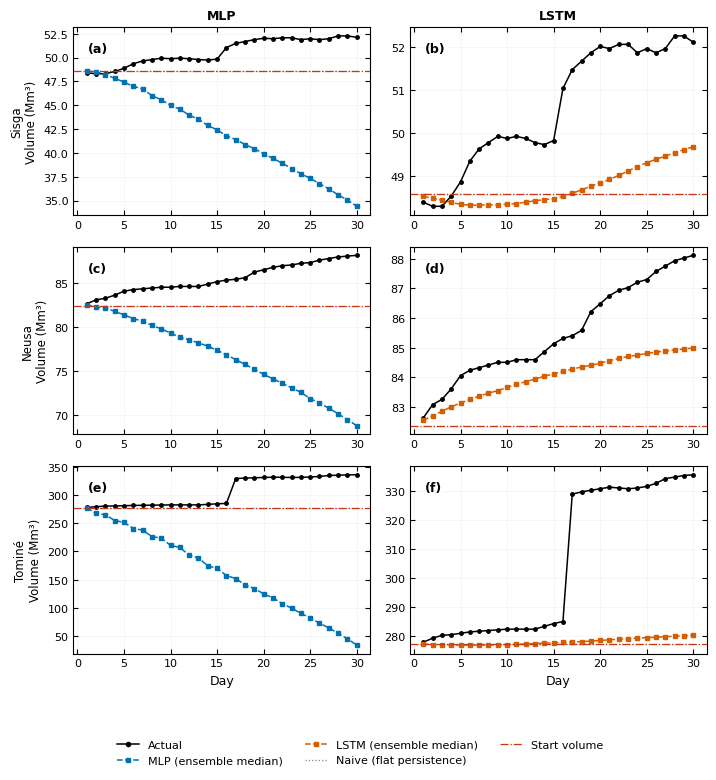

In [34]:
# Escenario A (realista, sin conocer precipitación futura

embalses_orden = list(dfs_merged.keys())
arquitecturas  = ['MLP', 'LSTM']
panel_letras = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

fig, axes = plt.subplots(len(embalses_orden), 2, figsize=(7.2, 7.5))
axes = np.atleast_2d(axes)
i_letra = 0
dias = np.arange(1, HORIZONTE_FORECAST + 1)

for fila, embalse in enumerate(embalses_orden):
    for col, arq in enumerate(arquitecturas):
        fc = forecasts_climatologia[embalse][arq]
        color = COLOR_ARCH[arq]
        ax = axes[fila, col]

        ax.plot(dias, fc['y_real_horizonte'], color=COLOR_ACTUAL, linewidth=1.1, marker='o', markersize=2.5)
        ax.plot(dias, fc['pred_vol'], color=color, linewidth=1.1, linestyle='--', marker='s', markersize=2.5)
        ax.plot(dias, fc['pred_naive_horizonte'], color=COLOR_NAIVE, linewidth=0.9, linestyle=':')
        ax.axhline(fc['vol_arranque'], color=COLOR_REF, linestyle='-.', linewidth=0.9)

        ax.text(0.05, 0.92, panel_letras[i_letra], transform=ax.transAxes,
                 fontsize=9, fontweight='bold', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.8))
        i_letra += 1

        ax.tick_params(direction='in', top=True, right=True)
        ax.grid(alpha=0.15, linewidth=0.5)

        if fila == 0:
            ax.set_title(arq, fontsize=9, fontweight='bold', pad=6)
        ax.set_ylabel(f'{embalse}\nVolume (Mm\u00b3)' if col == 0 else '', fontsize=8.5)
        if fila == len(embalses_orden) - 1:
            ax.set_xlabel('Day')

handles = [
    Line2D([0], [0], color=COLOR_ACTUAL, lw=1.1, marker='o', markersize=3, label='Actual'),
    Line2D([0], [0], color=COLOR_MLP,    lw=1.1, linestyle='--', marker='s', markersize=3, label='MLP (ensemble median)'),
    Line2D([0], [0], color=COLOR_LSTM,   lw=1.1, linestyle='--', marker='s', markersize=3, label='LSTM (ensemble median)'),
    Line2D([0], [0], color=COLOR_NAIVE,  lw=0.9, linestyle=':',  label='Naive (flat persistence)'),
    Line2D([0], [0], color=COLOR_REF,    lw=0.9, linestyle='-.', label='Start volume'),
]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout(rect=[0, 0.06, 1, 1])

fig.savefig(f'{RUTA_FIGURAS_PAPER}pdf/Figure5b_Forecast30d_climatologia.pdf', format='pdf', bbox_inches='tight')
fig.savefig(f'{RUTA_FIGURAS_PAPER}png/Figure5b_Forecast30d_climatologia.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

## 10. Pronóstico multi-step iterativo — Escenario B (evento/fecha específica)

Mapeo reproducible de una fecha real a los índices de test, con las 5 validaciones requeridas (existencia, rango permitido, ventana previa de 30 días, horizonte disponible, no leakage). No reemplaza el Escenario A — ambos se preservan y se comparan en la Sección 10.4.

### 10.1 Mapeo de fecha a índices de test (con validaciones)

In [35]:
def _obtener_split_referencia(embalse: str) -> dict:
    """Extrae val_size/ventana de las corridas reales de `embalse` y
    verifica que sean consistentes entre arquitecturas y semillas
    (no se asume, se comprueba)."""
    valores = set()
    for arq in ['MLP', 'LSTM']:
        for r in seleccion[embalse][arq]['corridas']:
            valores.add((r['val_size'], r['ventana']))
    if len(valores) != 1:
        raise ValueError(
            f"[{embalse}] val_size/ventana NO son consistentes entre "
            f"arquitecturas/semillas: {valores}. Revisar antes de continuar."
        )
    val_size, ventana = valores.pop()
    return {'val_size': val_size, 'ventana': ventana,
            'idx_test_inicio': val_size + ventana}


def mapear_fecha_a_indices(fecha_arranque: str,
                            embalses: list = None,
                            horizonte: int = HORIZONTE_FORECAST) -> dict:
    """
    Mapea FECHA_ARRANQUE (día ancla = último dato real ANTES del pronóstico,
    misma convención que vol_arranque / test['vol_t_minus_1'][idx] en
    Escenario A) a los índices de test necesarios para
    forecast_iterativo_individual/_ensemble.

    Aplica las 5 validaciones:
      1) la fecha existe en la serie
      2) está dentro del periodo de test permitido
      3) hay ventana de 30 días previa disponible (garantizado si idx_test>=0,
         por construcción de X_test)
      4) el horizonte de 30 días está disponible para evaluación
      5) no hay leakage (aserción cruzada de fechas + consistencia entre
         los tres embalses)

    Si cualquiera falla para cualquier embalse, lanza ValueError con mensaje
    explícito — no ejecuta un escenario parcial o silenciosamente incorrecto.
    """
    if embalses is None:
        embalses = list(dfs_merged.keys())

    try:
        fecha_ts = pd.Timestamp(fecha_arranque)
    except Exception as e:
        raise ValueError(f"FECHA_ARRANQUE='{fecha_arranque}' no es una fecha válida: {e}")

    resultado = {}
    idx_test_global = None

    for embalse in embalses:
        idx_serie_full = dfs_merged[embalse].index

        # (1) La fecha existe en la serie
        if fecha_ts < idx_serie_full.min() or fecha_ts > idx_serie_full.max():
            raise ValueError(
                f"[{embalse}] FECHA_ARRANQUE={fecha_ts.date()} está fuera del "
                f"rango de la serie ({idx_serie_full.min().date()} → "
                f"{idx_serie_full.max().date()})."
            )
        if fecha_ts not in idx_serie_full:
            raise ValueError(
                f"[{embalse}] FECHA_ARRANQUE={fecha_ts.date()} no existe en el "
                f"índice de dfs_merged['{embalse}']. Verifica el formato de fecha."
            )
        idx_serie = idx_serie_full.get_loc(fecha_ts)

        split = _obtener_split_referencia(embalse)
        idx_test_inicio = split['idx_test_inicio']

        ref_test  = seleccion[embalse]['MLP']['corridas'][0]['test']
        ref_Xtest = seleccion[embalse]['MLP']['corridas'][0]['X_test']
        n_test = len(ref_Xtest)
        if n_test != len(ref_test['y_real']):
            raise ValueError(
                f"[{embalse}] Inconsistencia interna: len(X_test)={n_test} "
                f"!= len(test['y_real'])={len(ref_test['y_real'])}."
            )

        idx_test = idx_serie - idx_test_inicio

        # (2) Dentro del periodo permitido (test set)
        if idx_test < 0:
            fecha_min_test = idx_serie_full[idx_test_inicio]
            raise ValueError(
                f"[{embalse}] FECHA_ARRANQUE={fecha_ts.date()} cae en train/val, "
                f"no en test. La fecha ancla más temprana permitida es "
                f"{fecha_min_test.date()}."
            )
        if idx_test > n_test - 1:
            fecha_max_test = idx_serie_full[idx_test_inicio + n_test - 1]
            raise ValueError(
                f"[{embalse}] FECHA_ARRANQUE={fecha_ts.date()} está después del "
                f"final del test set. La fecha ancla más tardía permitida "
                f"(sin exigir aún horizonte completo) es {fecha_max_test.date()}."
            )

        # (4) Horizonte de 30 días disponible para evaluación
        if idx_test + horizonte > n_test:
            fecha_max_valida = idx_serie_full[idx_test_inicio + n_test - horizonte]
            raise ValueError(
                f"[{embalse}] FECHA_ARRANQUE={fecha_ts.date()} no tiene "
                f"{horizonte} días reales posteriores en el test set para evaluar. "
                f"La fecha ancla más tardía permitida con horizonte completo es "
                f"{fecha_max_valida.date()}."
            )

        # (3) Ventana previa de 30 días: garantizada por construcción de X_test
        #     (idx_test >= 0 ya lo asegura).

        # (5) No leakage: aserción de consistencia de fechas
        fecha_dia1  = idx_serie_full[idx_serie + 1]
        fecha_dia30 = idx_serie_full[idx_serie + horizonte]
        fecha_check = idx_serie_full[idx_test_inicio + idx_test]
        if fecha_check != fecha_ts:
            raise ValueError(
                f"[{embalse}] Inconsistencia al mapear idx_test de vuelta a la "
                f"serie: esperado {fecha_ts.date()}, obtenido {fecha_check.date()}. "
                f"Abortando — no se ejecuta el escenario."
            )

        if idx_test_global is None:
            idx_test_global = idx_test
        elif idx_test_global != idx_test:
            raise ValueError(
                f"[{embalse}] idx_test={idx_test} difiere del calculado para otro "
                f"embalse (idx_test_global={idx_test_global}). Los tres embalses "
                f"deberían compartir el mismo calendario — revisar."
            )

        resultado[embalse] = {
            'idx_test': idx_test,
            'fecha_arranque': fecha_ts,
            'fecha_dia1': fecha_dia1,
            'fecha_dia30': fecha_dia30,
        }

    return resultado

### 10.2 Ejecución del pronóstico — Escenario B

In [36]:
# Escenario B — Evento/fecha específica

# Cambiar SOLO esta línea para generar un nuevo escenario:
FECHA_ARRANQUE = '2024-04-15'

mapeo_B = mapear_fecha_a_indices(FECHA_ARRANQUE, horizonte=HORIZONTE_FORECAST)

print(f"\nESCENARIO B — fecha de arranque: {FECHA_ARRANQUE}")
for embalse, info in mapeo_B.items():
    print(f"  {embalse:8s}: idx_test={info['idx_test']:4d}  "
          f"ancla={info['fecha_arranque'].date()}  "
          f"día1={info['fecha_dia1'].date()}  día30={info['fecha_dia30'].date()}")

forecasts_B = {}
for embalse in dfs_merged.keys():
    idx_test_B = mapeo_B[embalse]['idx_test']
    forecasts_B[embalse] = {}
    for arq in ['MLP', 'LSTM']:
        corridas = seleccion[embalse][arq]['corridas']
        fc = forecast_iterativo_ensemble(
            corridas, idx=idx_test_B, horizonte=HORIZONTE_FORECAST
        )
        forecasts_B[embalse][arq] = fc
        print(f"{embalse:8s} — {arq:4s} (N={fc['n_semillas']}): "
              f"MAE={fc['mae']:.3f}  |  Naive plano={fc['mae_naive_plano']:.3f}  |  "
              f"Skill={fc['skill']:.4f} ({'mejora ✓' if fc['skill'] < 1 else 'no mejora ✗'})")


ESCENARIO B — fecha de arranque: 2024-04-15
  Sisga   : idx_test=1128  ancla=2024-04-15  día1=2024-04-16  día30=2024-05-15
  Neusa   : idx_test=1128  ancla=2024-04-15  día1=2024-04-16  día30=2024-05-15
  Tominé  : idx_test=1128  ancla=2024-04-15  día1=2024-04-16  día30=2024-05-15
Sisga    — MLP  (N=10): MAE=5.904  |  Naive plano=1.725  |  Skill=3.4232 (no mejora ✗)
Sisga    — LSTM (N=10): MAE=0.345  |  Naive plano=1.725  |  Skill=0.1998 (mejora ✓)
Neusa    — MLP  (N=10): MAE=6.700  |  Naive plano=0.154  |  Skill=43.4078 (no mejora ✗)
Neusa    — LSTM (N=10): MAE=0.216  |  Naive plano=0.154  |  Skill=1.4021 (no mejora ✗)
Tominé   — MLP  (N=10): MAE=112.945  |  Naive plano=4.919  |  Skill=22.9602 (no mejora ✗)
Tominé   — LSTM (N=10): MAE=1.428  |  Naive plano=4.919  |  Skill=0.2904 (mejora ✓)


### 10.3 Función auxiliar de fechas para la tabla de validación

In [38]:
# Validación del pronóstico (Escenario A y B, ambos preservados)

def fechas_escenario(embalse: str, idx_test: int, horizonte: int = HORIZONTE_FORECAST) -> dict:
    """Reconstruye fecha de arranque y fechas día 1..horizonte para un
    (embalse, idx_test) ya validado. Usa el mismo split que
    mapear_fecha_a_indices — no reintroduce lógica distinta."""
    idx_serie_full = dfs_merged[embalse].index
    split = _obtener_split_referencia(embalse)
    idx_serie = split['idx_test_inicio'] + idx_test
    fecha_arranque = idx_serie_full[idx_serie]
    fechas_dias = [idx_serie_full[idx_serie + h] for h in range(1, horizonte + 1)]
    return {'fecha_arranque': fecha_arranque, 'fechas_dias': fechas_dias}

### 10.4 Construcción y comparación de la tabla de validación (Escenario A vs. B)

In [39]:
def construir_tabla_validacion(forecasts_dict: dict, idx_por_embalse: dict,
                                nombre_escenario: str,
                                horizonte: int = HORIZONTE_FORECAST) -> tuple:
    """
    idx_por_embalse: {embalse: idx_test}  (mismo idx_test usado para generar
    forecasts_dict, ya sea IDX_ARRANQUE (A, mismo valor los 3 embalses) o
    mapeo_B[embalse]['idx_test'] (B, por embalse)).
    Devuelve (tabla_detalle, tabla_resumen).
    """
    filas_detalle = []
    filas_resumen = []

    for embalse in forecasts_dict.keys():
        idx_test = idx_por_embalse[embalse]
        fch = fechas_escenario(embalse, idx_test, horizonte)

        for arq in ['MLP', 'LSTM']:
            fc = forecasts_dict[embalse][arq]

            rmse_modelo = float(np.sqrt(mean_squared_error(fc['y_real_horizonte'], fc['pred_vol'])))
            rmse_naive  = float(np.sqrt(mean_squared_error(fc['y_real_horizonte'], fc['pred_naive_horizonte'])))
            skill_rmse  = rmse_modelo / rmse_naive if rmse_naive > 0 else np.nan

            filas_resumen.append({
                'Escenario': nombre_escenario, 'Embalse': embalse, 'Arquitectura': arq,
                'Fecha inicio (ancla)': fch['fecha_arranque'].date(),
                'Volumen inicial (Mm3)': fc['vol_arranque'],
                'N semillas': fc['n_semillas'],
                'MAE': fc['mae'], 'RMSE': rmse_modelo, 'Skill (MAE)': fc['skill'],
                'MAE naive': fc['mae_naive_plano'], 'RMSE naive': rmse_naive,
                'Skill (RMSE)': skill_rmse,
            })

            for h in range(horizonte):
                filas_detalle.append({
                    'Escenario': nombre_escenario, 'Embalse': embalse, 'Arquitectura': arq,
                    'Fecha inicio (ancla)': fch['fecha_arranque'].date(),
                    'Volumen inicial (Mm3)': fc['vol_arranque'],
                    'Dia': h + 1, 'Fecha': fch['fechas_dias'][h].date(),
                    'Volumen real (Mm3)': float(fc['y_real_horizonte'][h]),
                    'Pronostico (Mm3)': float(fc['pred_vol'][h]),
                    'Naive persistencia (Mm3)': float(fc['pred_naive_horizonte'][h]),
                })

    return pd.DataFrame(filas_detalle), pd.DataFrame(filas_resumen)

# Escenario A: mismo IDX_ARRANQUE para los 3 embalses (Celda 36)
idx_A_por_embalse = {embalse: IDX_ARRANQUE for embalse in dfs_merged.keys()}
tabla_detalle_A, tabla_resumen_A = construir_tabla_validacion(
    forecasts, idx_A_por_embalse, nombre_escenario='A - Automatico (max. variacion)'
)

#Escenario B: idx_test por embalse desde mapeo_B
idx_B_por_embalse = {embalse: mapeo_B[embalse]['idx_test'] for embalse in dfs_merged.keys()}
tabla_detalle_B, tabla_resumen_B = construir_tabla_validacion(
    forecasts_B, idx_B_por_embalse, nombre_escenario=f'B - Evento ({FECHA_ARRANQUE})'
)

tabla_detalle_final = pd.concat([tabla_detalle_A, tabla_detalle_B], ignore_index=True)
tabla_resumen_final = pd.concat([tabla_resumen_A, tabla_resumen_B], ignore_index=True)

print("TABLA RESUMEN — Escenario A vs B")
print("=" * 100)
print(tabla_resumen_final.round(4).to_string(index=False))

TABLA RESUMEN — Escenario A vs B
                      Escenario Embalse Arquitectura Fecha inicio (ancla)  Volumen inicial (Mm3)  N semillas      MAE     RMSE  Skill (MAE)  MAE naive  RMSE naive  Skill (RMSE)
A - Automatico (max. variacion)   Sisga          MLP           2022-04-23                48.5866          10   5.4478   6.7669       2.6038     2.0922      2.4582        2.7527
A - Automatico (max. variacion)   Sisga         LSTM           2022-04-23                48.5866          10   0.3526   0.4547       0.1685     2.0922      2.4582        0.1850
A - Automatico (max. variacion)   Neusa          MLP           2022-04-23                82.3641          10   8.4159  10.0905       2.6537     3.1714      3.5495        2.8428
A - Automatico (max. variacion)   Neusa         LSTM           2022-04-23                82.3641          10   0.9517   1.2518       0.3001     3.1714      3.5495        0.3527
A - Automatico (max. variacion)  Tominé          MLP           2022-04-23         

### 10.5 Exportación de la validación (CSV + Excel)

In [40]:
RUTA_RESULTADOS_PRONOSTICOS = RUTA_BASE + 'Resultados_Pronosticos/'
os.makedirs(RUTA_RESULTADOS_PRONOSTICOS, exist_ok=True)

tabla_detalle_final.to_csv(RUTA_RESULTADOS_PRONOSTICOS + 'forecast_validacion_detalle.csv', index=False)
tabla_resumen_final.to_csv(RUTA_RESULTADOS_PRONOSTICOS + 'forecast_validacion_resumen.csv', index=False)

with pd.ExcelWriter(RUTA_RESULTADOS_PRONOSTICOS + 'forecast_validacion.xlsx') as writer:
    tabla_resumen_final.to_excel(writer, sheet_name='Resumen', index=False)
    tabla_detalle_final.to_excel(writer, sheet_name='Detalle_diario', index=False)

print("Guardado en:", RUTA_RESULTADOS_PRONOSTICOS)

Guardado en: /content/drive/MyDrive/Embalses/Pronostico/Resultados_Pronosticos/


### 10.6 Figura — Escenario B (30 días, con fechas reales)

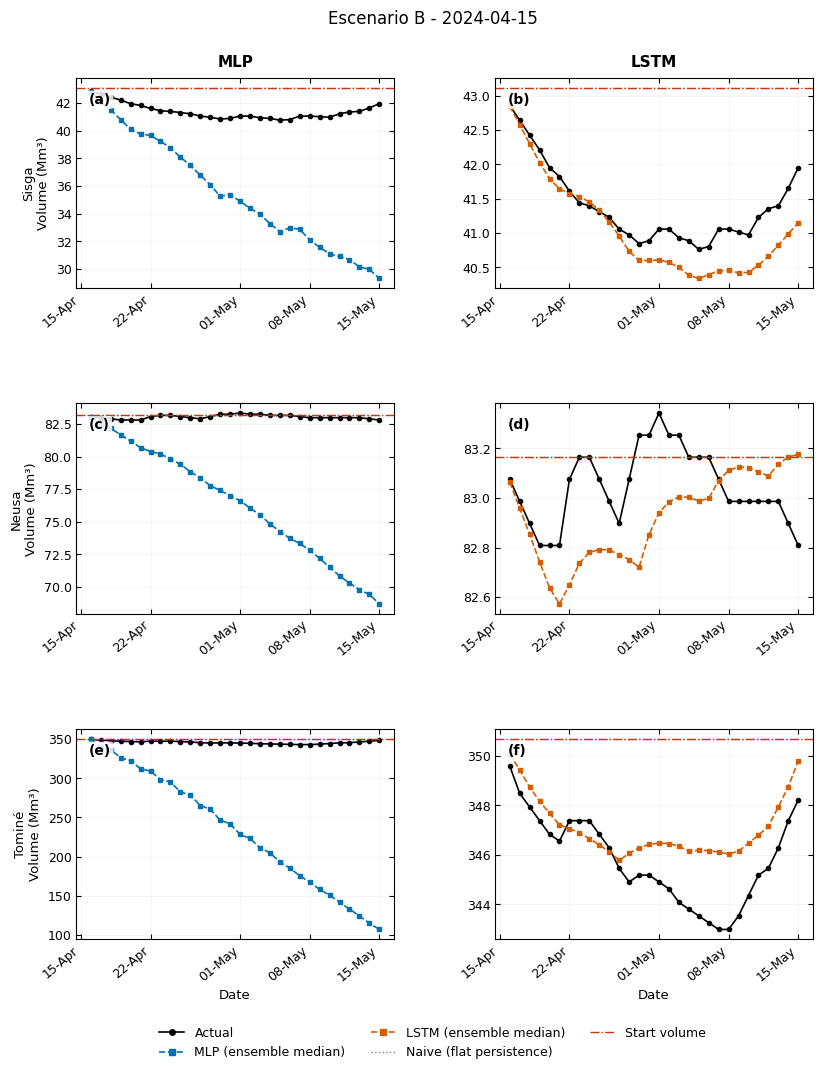

Figura Escenario B guardada en: /content/drive/MyDrive/Embalses/Pronostico/Figuras_Paper/


In [41]:
embalses_orden = list(dfs_merged.keys())
arquitecturas  = ['MLP', 'LSTM']
panel_letras = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

fig, axes = plt.subplots(len(embalses_orden), 2, figsize=(9.5, 10.5))
axes = np.atleast_2d(axes)
i_letra = 0

for fila, embalse in enumerate(embalses_orden):
    idx_test_B = mapeo_B[embalse]['idx_test']
    fch = fechas_escenario(embalse, idx_test_B, HORIZONTE_FORECAST)
    fechas_x = fch['fechas_dias']

    for col, arq in enumerate(arquitecturas):
        fc = forecasts_B[embalse][arq]
        color = COLOR_ARCH[arq]
        ax = axes[fila, col]

        ax.plot(fechas_x, fc['y_real_horizonte'], color=COLOR_ACTUAL, linewidth=1.2, marker='o', markersize=3)
        ax.plot(fechas_x, fc['pred_vol'], color=color, linewidth=1.2, linestyle='--', marker='s', markersize=3)
        ax.plot(fechas_x, fc['pred_naive_horizonte'], color=COLOR_NAIVE, linewidth=1.0, linestyle=':')
        ax.axhline(fc['vol_arranque'], color=COLOR_REF, linestyle='-.', linewidth=1.0)

        ax.text(0.04, 0.93, panel_letras[i_letra], transform=ax.transAxes,
                 fontsize=10, fontweight='bold', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.85))
        i_letra += 1

        ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=6))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
        plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)

        ax.tick_params(direction='in', top=True, right=True, labelsize=9)
        ax.grid(alpha=0.15, linewidth=0.5)

        if fila == 0:
            ax.set_title(arq, fontsize=11, fontweight='bold', pad=8)
        ax.set_ylabel(f'{embalse}\nVolume (Mm\u00b3)' if col == 0 else '', fontsize=9.5)
        if fila == len(embalses_orden) - 1:
            ax.set_xlabel('Date', fontsize=9.5)

handles = [
    Line2D([0], [0], color=COLOR_ACTUAL, lw=1.2, marker='o', markersize=4, label='Actual'),
    Line2D([0], [0], color=COLOR_MLP,    lw=1.2, linestyle='--', marker='s', markersize=4, label='MLP (ensemble median)'),
    Line2D([0], [0], color=COLOR_LSTM,   lw=1.2, linestyle='--', marker='s', markersize=4, label='LSTM (ensemble median)'),
    Line2D([0], [0], color=COLOR_NAIVE,  lw=1.0, linestyle=':',  label='Naive (flat persistence)'),
    Line2D([0], [0], color=COLOR_REF,    lw=1.0, linestyle='-.', label='Start volume'),
]

fig.suptitle(f'Escenario B - {FECHA_ARRANQUE}', fontsize=12, y=0.995)
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False,
           bbox_to_anchor=(0.5, -0.015), fontsize=9)

fig.subplots_adjust(top=0.93, bottom=0.11, hspace=0.55, wspace=0.32)

fig.savefig(f'{RUTA_FIGURAS_PAPER}pdf/Figure6_Forecast30d_EscenarioB.pdf', format='pdf', bbox_inches='tight')
fig.savefig(f'{RUTA_FIGURAS_PAPER}png/Figure6_Forecast30d_EscenarioB.png', format='png', dpi=600, bbox_inches='tight')
plt.show()
print("Figura Escenario B guardada en:", RUTA_FIGURAS_PAPER)

In [42]:
# Escenario B, version realista (sin precipitacion futura conocida)

forecasts_B_clima = {}
for embalse in dfs_merged.keys():
    idx_test_B = mapeo_B[embalse]['idx_test']
    fechas_test_embalse = dfs_merged[embalse].index[
        seleccion[embalse]['MLP']['corridas'][0]['val_size'] + seleccion[embalse]['MLP']['corridas'][0]['ventana']:
    ]
    forecasts_B_clima[embalse] = {}
    for arq in ['MLP', 'LSTM']:
        corridas = seleccion[embalse][arq]['corridas']
        fc = forecast_iterativo_ensemble(
            corridas, idx=idx_test_B, horizonte=HORIZONTE_FORECAST,
            modo_precip='climatologia',
            climatologia=CLIMATOLOGIA_PRECIP[embalse],
            fechas_test=fechas_test_embalse,
        )
        forecasts_B_clima[embalse][arq] = fc
        print(f"{embalse:8s} — {arq:4s}: MAE={fc['mae']:.3f}  |  Skill={fc['skill']:.4f}")

Sisga    — MLP : MAE=6.155  |  Skill=3.5688
Sisga    — LSTM: MAE=0.179  |  Skill=0.1036
Neusa    — MLP : MAE=6.281  |  Skill=40.6935
Neusa    — LSTM: MAE=0.321  |  Skill=2.0807
Tominé   — MLP : MAE=113.123  |  Skill=22.9964
Tominé   — LSTM: MAE=0.908  |  Skill=0.1845


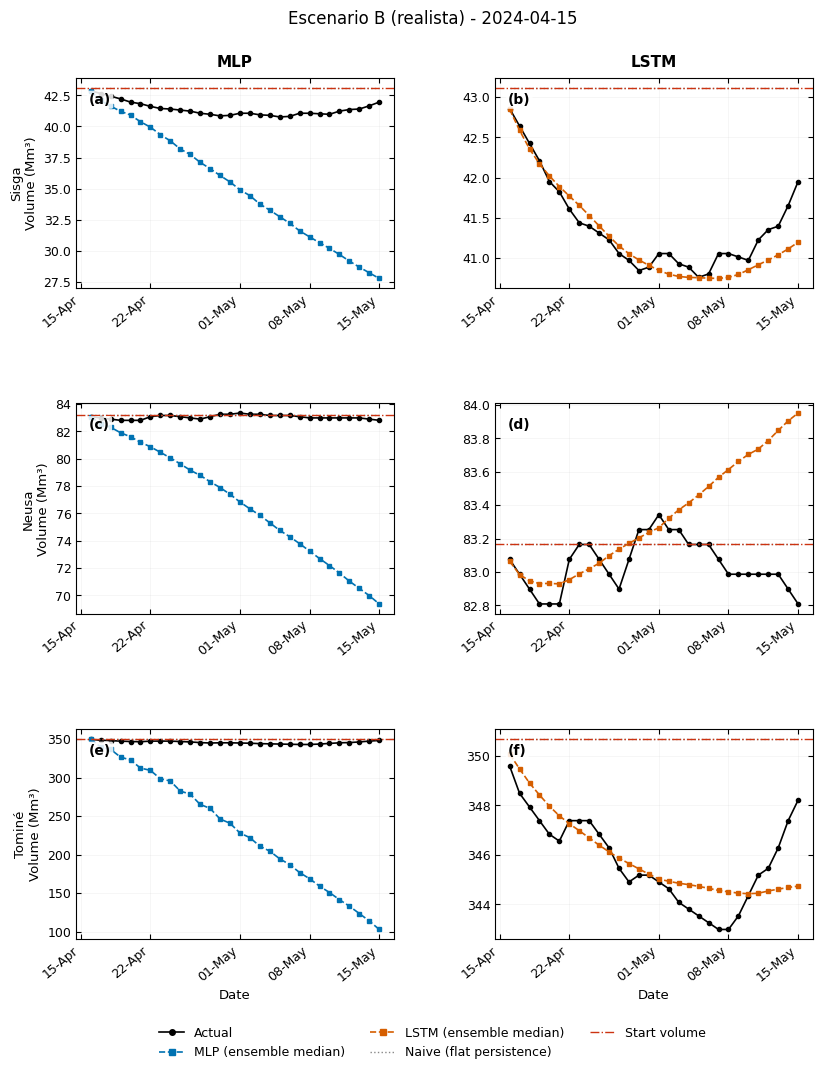

In [43]:
embalses_orden = list(dfs_merged.keys())
arquitecturas  = ['MLP', 'LSTM']
panel_letras = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

fig, axes = plt.subplots(len(embalses_orden), 2, figsize=(9.5, 10.5))
axes = np.atleast_2d(axes)
i_letra = 0

for fila, embalse in enumerate(embalses_orden):
    idx_test_B = mapeo_B[embalse]['idx_test']
    fch = fechas_escenario(embalse, idx_test_B, HORIZONTE_FORECAST)
    fechas_x = fch['fechas_dias']

    for col, arq in enumerate(arquitecturas):
        fc = forecasts_B_clima[embalse][arq]
        color = COLOR_ARCH[arq]
        ax = axes[fila, col]

        ax.plot(fechas_x, fc['y_real_horizonte'], color=COLOR_ACTUAL, linewidth=1.2, marker='o', markersize=3)
        ax.plot(fechas_x, fc['pred_vol'], color=color, linewidth=1.2, linestyle='--', marker='s', markersize=3)
        ax.plot(fechas_x, fc['pred_naive_horizonte'], color=COLOR_NAIVE, linewidth=1.0, linestyle=':')
        ax.axhline(fc['vol_arranque'], color=COLOR_REF, linestyle='-.', linewidth=1.0)

        ax.text(0.04, 0.93, panel_letras[i_letra], transform=ax.transAxes,
                 fontsize=10, fontweight='bold', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.85))
        i_letra += 1

        ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=6))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
        plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)

        ax.tick_params(direction='in', top=True, right=True, labelsize=9)
        ax.grid(alpha=0.15, linewidth=0.5)

        if fila == 0:
            ax.set_title(arq, fontsize=11, fontweight='bold', pad=8)
        ax.set_ylabel(f'{embalse}\nVolume (Mm\u00b3)' if col == 0 else '', fontsize=9.5)
        if fila == len(embalses_orden) - 1:
            ax.set_xlabel('Date', fontsize=9.5)

handles = [
    Line2D([0], [0], color=COLOR_ACTUAL, lw=1.2, marker='o', markersize=4, label='Actual'),
    Line2D([0], [0], color=COLOR_MLP,    lw=1.2, linestyle='--', marker='s', markersize=4, label='MLP (ensemble median)'),
    Line2D([0], [0], color=COLOR_LSTM,   lw=1.2, linestyle='--', marker='s', markersize=4, label='LSTM (ensemble median)'),
    Line2D([0], [0], color=COLOR_NAIVE,  lw=1.0, linestyle=':',  label='Naive (flat persistence)'),
    Line2D([0], [0], color=COLOR_REF,    lw=1.0, linestyle='-.', label='Start volume'),
]

fig.suptitle(f'Escenario B (realista) - {FECHA_ARRANQUE}', fontsize=12, y=0.995)
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False,
           bbox_to_anchor=(0.5, -0.015), fontsize=9)

fig.subplots_adjust(top=0.93, bottom=0.11, hspace=0.55, wspace=0.32)

fig.savefig(f'{RUTA_FIGURAS_PAPER}pdf/Figure6b_Forecast30d_EscenarioB_climatologia.pdf', format='pdf', bbox_inches='tight')
fig.savefig(f'{RUTA_FIGURAS_PAPER}png/Figure6b_Forecast30d_EscenarioB_climatologia.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

## 11. Evaluación rolling multi-origen + test de significancia

Evalúa el pronóstico de 30 días en muchos orígenes distribuidos por el test set, y aplica Wilcoxon pareado (modelo vs. naive) sobre esa muestra

In [ ]:
# Evaluacion rolling multi-origen del pronostico de 30 dias.
# STRIDE controla el costo de computo: STRIDE=5 evalua 1 de cada 5 origenes
# posibles del test set. Bajalo (p.ej. 1) si el tiempo de ejecucion lo permite;
# subirlo (p.ej. 10-15) si se necesita acelerar.
# Imprime progreso y ETA con el mismo criterio que entrenar_multisemilla
# (Celda 19 de 01_MODEL_TRAINING.ipynb): promedio movil de tiempo por
# iteracion x iteraciones restantes.

import time

STRIDE = 15

resultados_rolling = {embalse: {arq: [] for arq in ['MLP', 'LSTM']} for embalse in dfs_merged.keys()}

n_test_ref = len(seleccion[list(dfs_merged.keys())[0]]['MLP']['corridas'][0]['test']['y_real'])
origenes = list(range(0, n_test_ref - HORIZONTE_FORECAST, STRIDE))

embalses_lista = list(dfs_merged.keys())
total_iter = len(embalses_lista) * 2 * len(origenes)   # embalses x arquitecturas x origenes
print(f"Evaluando {len(origenes)} origenes x {len(embalses_lista)} embalses x 2 arquitecturas "
      f"= {total_iter} pronosticos de 30 dias (stride={STRIDE})...")

t0_total    = time.time()
tiempos     = []
iter_actual = 0

for embalse in embalses_lista:
    for arq in ['MLP', 'LSTM']:
        corridas = seleccion[embalse][arq]['corridas']
        for idx0 in origenes:
            t0 = time.time()
            fc = forecast_iterativo_ensemble(corridas, idx=idx0, horizonte=HORIZONTE_FORECAST)
            resultados_rolling[embalse][arq].append({
                'idx': idx0, 'mae': fc['mae'], 'mae_naive': fc['mae_naive_plano'], 'skill': fc['skill'],
            })
            dt = time.time() - t0
            tiempos.append(dt)
            iter_actual += 1

            # Imprime cada 20 iteraciones (y la última) para no inundar el output.
            if iter_actual % 20 == 0 or iter_actual == total_iter:
                eta_min = ((total_iter - iter_actual) * np.mean(tiempos)) / 60
                pct = iter_actual / total_iter * 100
                print(f"  [{iter_actual:5d}/{total_iter}] ({pct:5.1f}%) "
                      f"{embalse:8s} {arq:4s} idx={idx0:4d} | "
                      f"t/iter={np.mean(tiempos):.2f}s | ETA≈{eta_min:.1f} min")

    print(f"  {embalse}: listo ({(time.time() - t0_total)/60:.1f} min transcurridos)")

t_total_min = (time.time() - t0_total) / 60
print(f"\nEvaluacion rolling completa en {t_total_min:.1f} min "
      f"({t_total_min/60:.2f} h) — {total_iter} pronosticos de 30 dias evaluados.")

Evaluando 91 origenes x 3 embalses x 2 arquitecturas = 546 pronosticos de 30 dias (stride=15)...
  [   20/546] (  3.7%) Sisga    MLP  idx= 285 | t/iter=33.32s | ETA≈292.1 min
  [   40/546] (  7.3%) Sisga    MLP  idx= 585 | t/iter=32.90s | ETA≈277.4 min
  [   60/546] ( 11.0%) Sisga    MLP  idx= 885 | t/iter=32.96s | ETA≈266.9 min
  [   80/546] ( 14.7%) Sisga    MLP  idx=1185 | t/iter=33.09s | ETA≈257.0 min
  [  100/546] ( 18.3%) Sisga    LSTM idx= 120 | t/iter=33.27s | ETA≈247.3 min
  [  120/546] ( 22.0%) Sisga    LSTM idx= 420 | t/iter=33.49s | ETA≈237.8 min
  [  140/546] ( 25.6%) Sisga    LSTM idx= 720 | t/iter=33.54s | ETA≈227.0 min
  [  160/546] ( 29.3%) Sisga    LSTM idx=1020 | t/iter=33.63s | ETA≈216.3 min
  [  180/546] ( 33.0%) Sisga    LSTM idx=1320 | t/iter=33.68s | ETA≈205.5 min
  Sisga: listo (102.1 min transcurridos)
  [  200/546] ( 36.6%) Neusa    MLP  idx= 255 | t/iter=33.65s | ETA≈194.0 min
  [  220/546] ( 40.3%) Neusa    MLP  idx= 555 | t/iter=33.66s | ETA≈182.9 min
  [ 

In [ ]:
# Resumen + test de Wilcoxon pareado (MAE_modelo - MAE_naive) por origen
filas_rolling_resumen = []
for embalse in dfs_merged.keys():
    for arq in ['MLP', 'LSTM']:
        datos = resultados_rolling[embalse][arq]
        maes       = np.array([d['mae'] for d in datos])
        maes_naive = np.array([d['mae_naive'] for d in datos])
        skills     = np.array([d['skill'] for d in datos])

        try:
            stat, p_val = wilcoxon(maes - maes_naive)
        except ValueError:
            stat, p_val = np.nan, np.nan

        filas_rolling_resumen.append({
            'Embalse': embalse, 'Arquitectura': arq,
            'N origenes': len(datos),
            'Skill (media±DE)': f"{skills.mean():.4f} ± {skills.std():.4f}",
            'Skill (mediana)': f"{np.median(skills):.4f}",
            '% origenes con skill<1 (mejora)': f"{np.mean(skills < 1) * 100:.1f}%",
            'Wilcoxon stat': f"{stat:.3f}" if not np.isnan(stat) else "N/A",
            'Wilcoxon p': f"{p_val:.4g}" if not np.isnan(p_val) else "N/A",
        })

df_rolling_resumen = pd.DataFrame(filas_rolling_resumen)
print("EVALUACION ROLLING MULTI-ORIGEN — PRONOSTICO 30 DIAS")
print("=" * 100)
print(df_rolling_resumen.to_string(index=False))

EVALUACION ROLLING MULTI-ORIGEN — PRONOSTICO 30 DIAS
Embalse Arquitectura  N origenes  Skill (media±DE) Skill (mediana) % origenes con skill<1 (mejora) Wilcoxon stat Wilcoxon p
  Sisga          MLP          91  7.3733 ± 20.1401          2.4606                            7.7%        48.000  5.778e-16
  Sisga         LSTM          91   1.0769 ± 2.3066          0.3859                           74.7%       693.000  3.006e-08
  Neusa          MLP          91 13.4126 ± 15.3245          8.6911                            4.4%       103.000  3.374e-15
  Neusa         LSTM          91   0.9397 ± 1.2407          0.6085                           72.5%       762.000  1.379e-07
 Tominé          MLP          91 33.9538 ± 40.4022         18.9157                            0.0%         0.000  1.192e-16
 Tominé         LSTM          91   0.6509 ± 0.6237          0.4387                           82.4%       351.000  5.399e-12


### Evaluacion rolling multi-origen, version REALISTA (sin lluvia futura).

In [ ]:
# STRIDE mas alto que la corrida 'real' para acotar el tiempo de computo
# (es una muestra mas chica de origenes, pero sigue siendo multi-origen).

STRIDE_CLIMA = 60

resultados_rolling_clima = {embalse: {arq: [] for arq in ['MLP', 'LSTM']} for embalse in dfs_merged.keys()}

n_test_ref = len(seleccion[list(dfs_merged.keys())[0]]['MLP']['corridas'][0]['test']['y_real'])
origenes_clima = list(range(0, n_test_ref - HORIZONTE_FORECAST, STRIDE_CLIMA))

embalses_lista = list(dfs_merged.keys())
total_iter = len(embalses_lista) * 2 * len(origenes_clima)
print(f"Evaluando {len(origenes_clima)} origenes x {len(embalses_lista)} embalses x 2 arquitecturas "
      f"= {total_iter} pronosticos de 30 dias, modo_precip='climatologia' (stride={STRIDE_CLIMA})...")

t0_total    = time.time()
tiempos     = []
iter_actual = 0

for embalse in embalses_lista:
    fechas_test_embalse = dfs_merged[embalse].index[
        seleccion[embalse]['MLP']['corridas'][0]['val_size'] + seleccion[embalse]['MLP']['corridas'][0]['ventana']:
    ]
    for arq in ['MLP', 'LSTM']:
        corridas = seleccion[embalse][arq]['corridas']
        for idx0 in origenes_clima:
            t0 = time.time()
            fc = forecast_iterativo_ensemble(
                corridas, idx=idx0, horizonte=HORIZONTE_FORECAST,
                modo_precip='climatologia',
                climatologia=CLIMATOLOGIA_PRECIP[embalse],
                fechas_test=fechas_test_embalse,
            )
            resultados_rolling_clima[embalse][arq].append({
                'idx': idx0, 'mae': fc['mae'], 'mae_naive': fc['mae_naive_plano'], 'skill': fc['skill'],
            })
            dt = time.time() - t0
            tiempos.append(dt)
            iter_actual += 1

            if iter_actual % 20 == 0 or iter_actual == total_iter:
                eta_min = ((total_iter - iter_actual) * np.mean(tiempos)) / 60
                pct = iter_actual / total_iter * 100
                print(f"  [{iter_actual:5d}/{total_iter}] ({pct:5.1f}%) "
                      f"{embalse:8s} {arq:4s} idx={idx0:4d} | "
                      f"t/iter={np.mean(tiempos):.2f}s | ETA≈{eta_min:.1f} min")

    print(f"  {embalse}: listo ({(time.time() - t0_total)/60:.1f} min transcurridos)")

t_total_min = (time.time() - t0_total) / 60
print(f"\nEvaluacion rolling (climatologia) completa en {t_total_min:.1f} min "
      f"({t_total_min/60:.2f} h) — {total_iter} pronosticos de 30 dias evaluados.")

# Resumen + Wilcoxon (mismo criterio que la version 'real')
filas_rolling_clima = []
for embalse in dfs_merged.keys():
    for arq in ['MLP', 'LSTM']:
        datos = resultados_rolling_clima[embalse][arq]
        maes       = np.array([d['mae'] for d in datos])
        maes_naive = np.array([d['mae_naive'] for d in datos])
        skills     = np.array([d['skill'] for d in datos])
        try:
            stat, p_val = wilcoxon(maes - maes_naive)
        except ValueError:
            stat, p_val = np.nan, np.nan
        filas_rolling_clima.append({
            'Embalse': embalse, 'Arquitectura': arq,
            'N origenes': len(datos),
            'Skill (media±DE)': f"{skills.mean():.4f} ± {skills.std():.4f}",
            'Skill (mediana)': f"{np.median(skills):.4f}",
            '% origenes con skill<1 (mejora)': f"{np.mean(skills < 1) * 100:.1f}%",
            'Wilcoxon stat': f"{stat:.3f}" if not np.isnan(stat) else "N/A",
            'Wilcoxon p': f"{p_val:.4g}" if not np.isnan(p_val) else "N/A",
        })

df_rolling_resumen_clima = pd.DataFrame(filas_rolling_clima)
print("\nEVALUACION ROLLING MULTI-ORIGEN — CLIMATOLOGIA (sin conocer lluvia futura)")
print("=" * 100)
print(df_rolling_resumen_clima.to_string(index=False))

Evaluando 23 origenes x 3 embalses x 2 arquitecturas = 138 pronosticos de 30 dias, modo_precip='climatologia' (stride=60)...
  [   20/138] ( 14.5%) Sisga    MLP  idx=1140 | t/iter=34.33s | ETA≈67.5 min
  [   40/138] ( 29.0%) Sisga    LSTM idx= 960 | t/iter=34.53s | ETA≈56.4 min
  Sisga: listo (26.6 min transcurridos)
  [   60/138] ( 43.5%) Neusa    MLP  idx= 780 | t/iter=34.53s | ETA≈44.9 min
  [   80/138] ( 58.0%) Neusa    LSTM idx= 600 | t/iter=34.48s | ETA≈33.3 min
  Neusa: listo (53.0 min transcurridos)
  [  100/138] ( 72.5%) Tominé   MLP  idx= 420 | t/iter=34.48s | ETA≈21.8 min
  [  120/138] ( 87.0%) Tominé   LSTM idx= 240 | t/iter=34.44s | ETA≈10.3 min
  [  138/138] (100.0%) Tominé   LSTM idx=1320 | t/iter=34.51s | ETA≈0.0 min
  Tominé: listo (79.4 min transcurridos)

Evaluacion rolling (climatologia) completa en 79.4 min (1.32 h) — 138 pronosticos de 30 dias evaluados.

EVALUACION ROLLING MULTI-ORIGEN — CLIMATOLOGIA (sin conocer lluvia futura)
Embalse Arquitectura  N origenes  S

## 12. Tablas

Las 10 tablas se construyen directamente desde los objetos ya calculados en las secciones anteriores (checkpoints, selección de configuración, ensemble, validación del pronóstico) — ningún valor se recalcula de forma distinta.

### 12.1 Construcción de las tablas 1 y 2 (configuración experimental y selección)

In [ ]:
# Tabla 1: configuración experimental (directo de checkpoints)

def construir_tabla_configuracion(configs: dict) -> pd.DataFrame:
    filas = []
    for nombre_config, resultados in configs.items():
        for embalse, modelos in resultados.items():
            for arq, corridas in modelos.items():
                semillas    = sorted(r['seed'] for r in corridas)
                epocas      = [len(r['history']['loss']) for r in corridas]
                ventanas    = {r['ventana'] for r in corridas}
                losses      = {r['loss'] for r in corridas}
                huber_deltas = {r['huber_delta'] for r in corridas}
                lr_scheds   = {r['lr_scheduler'] for r in corridas}
                train_raws  = {r['train_raw'] for r in corridas}
                val_raws    = {r['val_raw'] for r in corridas}
                train_sizes = {r['train_size'] for r in corridas}
                val_sizes   = {r['val_size'] for r in corridas}
                test_sizes  = {len(r['X_test']) for r in corridas}
                n_deltas    = {len(r['dataset_abs']) - 1 for r in corridas}
                formatos_3d = {r['formato_3d'] for r in corridas}

                for etiqueta, conjunto in [
                    ('ventana', ventanas), ('loss', losses), ('huber_delta', huber_deltas),
                    ('lr_scheduler', lr_scheds), ('train_raw', train_raws), ('val_raw', val_raws),
                    ('train_size', train_sizes), ('val_size', val_sizes),
                    ('test_size', test_sizes), ('n_delta', n_deltas), ('formato_3d', formatos_3d),
                ]:
                    if len(conjunto) != 1:
                        raise ValueError(
                            f"[{nombre_config}/{embalse}/{arq}] valores inconsistentes de "
                            f"'{etiqueta}' entre semillas: {conjunto}"
                        )

                filas.append({
                    'Config': nombre_config, 'Embalse': embalse, 'Arquitectura': arq,
                    'Formato entrada': '3D (ventana,2)' if formatos_3d.pop() else '2D (ventana*2)',
                    'Loss': losses.pop(),
                    'Huber delta': next(iter(huber_deltas)),
                    'LR scheduler': next(iter(lr_scheds)),
                    'Ventana (dias)': next(iter(ventanas)),
                    'N semillas': len(semillas),
                    'Semillas': str(semillas),
                    'N dias serie (N)': next(iter(n_deltas)) + 1,
                    'N delta (N-1)': next(iter(n_deltas)),
                    'Train raw (70%)': next(iter(train_raws)),
                    'Val raw (80% acum.)': next(iter(val_raws)),
                    'Train size (muestras)': next(iter(train_sizes)),
                    'Val size (muestras)': next(iter(val_sizes)),
                    'Test size (muestras)': next(iter(test_sizes)),
                    'Epocas entrenadas (media)': np.mean(epocas),
                    'Epocas entrenadas (min-max)': f"{min(epocas)}-{max(epocas)}",
                })
    return pd.DataFrame(filas)


tabla_configuracion_experimental = construir_tabla_configuracion(CONFIGS)
print("TABLA 1 — CONFIGURACIÓN EXPERIMENTAL (directo de checkpoints)")
print("=" * 100)
print(tabla_configuracion_experimental.to_string(index=False))

# Tabla de ganadores de selección de configuración (derivado de `seleccion`, ya calculado)

filas_ganadores = []
for embalse, por_arq in seleccion.items():
    for arq, info in por_arq.items():
        filas_ganadores.append({
            'Embalse': embalse, 'Arquitectura': arq,
            'Config ganadora': info['config_ganadora'],
            'MAE val medio (Mm3)': info['mae_val_medio'],
            'N semillas': len(info['corridas']),
        })
tabla_seleccion_ganadores = pd.DataFrame(filas_ganadores)
print("\nTABLA — CONFIGURACIÓN GANADORA POR EMBALSE/ARQUITECTURA")
print(tabla_seleccion_ganadores.round(4).to_string(index=False))

TABLA 1 — CONFIGURACIÓN EXPERIMENTAL (directo de checkpoints)
  Config Embalse Arquitectura Formato entrada  Loss  Huber delta  LR scheduler  Ventana (dias)  N semillas                                 Semillas  N dias serie (N)  N delta (N-1)  Train raw (70%)  Val raw (80% acum.)  Train size (muestras)  Val size (muestras)  Test size (muestras)  Epocas entrenadas (media) Epocas entrenadas (min-max)
     mse   Sisga          MLP  2D (ventana*2)   mse          NaN         False              30          10 [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]              6940           6939             4857                 5551                   4827                 5521                  1388                       26.7                       19-39
     mse   Sisga         LSTM  3D (ventana,2)   mse          NaN         False              30          10 [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]              6940           6939             4857                 5551                   4827                 

### 11.2 Exportación consolidada (CSV individuales + Excel)

In [ ]:
RUTA_TABLAS_PAPER = RUTA_BASE + 'Tablas_Paper/'
os.makedirs(RUTA_TABLAS_PAPER, exist_ok=True)

tablas = {
    '1_config_experimental':        tabla_configuracion_experimental,
    '2a_seleccion_detalle':         df_seleccion_detalle,
    '2b_seleccion_ganadores':       tabla_seleccion_ganadores,
    '3_resultados_test':            df_resumen_final,
    '4_comparacion_arquitecturas':  df_arquitecturas,
    '5_ensemble':                   df_ensemble,
    '6a_forecast_resumen_A':        tabla_resumen_A,
    '6b_forecast_detalle_A':        tabla_detalle_A,
    '7a_escenarios_resumen_AB':     tabla_resumen_final,
    '7b_escenarios_detalle_AB':     tabla_detalle_final,
    '8_estacionariedad_delta':      df_estacionariedad_delta,
    '9_precip_real_vs_climatologia': df_comparacion_precip,
    '10_rolling_multiorigen':       df_rolling_resumen,
    '11_rolling_multiorigen_clima': df_rolling_resumen_clima,
}

for nombre, df in tablas.items():
    df.to_csv(f'{RUTA_TABLAS_PAPER}Tabla_{nombre}.csv', index=False)

with pd.ExcelWriter(RUTA_TABLAS_PAPER + 'Tablas_Paper_Completo.xlsx') as writer:
    for nombre, df in tablas.items():
        hoja = nombre[:31]
        df.to_excel(writer, sheet_name=hoja, index=False)

print(f"{len(tablas)} tablas exportadas (CSV individuales + Excel consolidado) en:")
print(RUTA_TABLAS_PAPER)

14 tablas exportadas (CSV individuales + Excel consolidado) en:
/content/drive/MyDrive/Embalses/Pronostico/Tablas_Paper/


In [ ]:
!jupyter nbconvert --to html "{RUTA_BASE}02_PAPER_ANALYSIS.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Embalses/Pronostico/02_PAPER_ANALYSIS.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 1545296 bytes to /content/drive/MyDrive/Embalses/Pronostico/02_PAPER_ANALYSIS.html
